In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

warnings.filterwarnings('ignore')

# Establecer semilla para reproducibilidad
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
print(f'✓ Semilla global establecida: {SEED}')

DATASET_CSV = 'dataset-uci.csv'
print('Ruta de trabajo:', os.getcwd())

df = pd.read_csv(DATASET_CSV, sep=';', header=0)
print(f'✓ Lectura exitosa — forma: {df.shape}')

# Verificar valores nulos
print('\n' + '='*60)
print('VERIFICACIÓN DE VALORES NULOS')
print('='*60)
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': porcentaje_nulos})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(df_nulos) > 0:
    print(f'\n⚠ Se encontraron {len(df_nulos)} columnas con valores nulos:')
    display(df_nulos)
    
    plt.figure(figsize=(12, 6))
    plt.barh(df_nulos.index, df_nulos['Porcentaje'], color='#e74c3c')
    plt.xlabel('Porcentaje de valores nulos (%)')
    plt.title('Distribución de Valores Nulos por Feature', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No se encontraron valores nulos en el dataset')

print('='*60)

display(df.head())
df.info()

✓ Semilla global establecida: 40
Ruta de trabajo: c:\Users\Kotler\Downloads\ML_Proyecto\ML_ProyectoFinal
✓ Lectura exitosa — forma: (319, 39)

VERIFICACIÓN DE VALORES NULOS
✅ No se encontraron valores nulos en el dataset


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

## 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Análisis de la distribución de clases y correlaciones entre variables.

Distribución de clases:
Gallstone Status
0    161
1    158
Name: count, dtype: int64

Proporción:
Gallstone Status
0    0.504702
1    0.495298
Name: proportion, dtype: float64


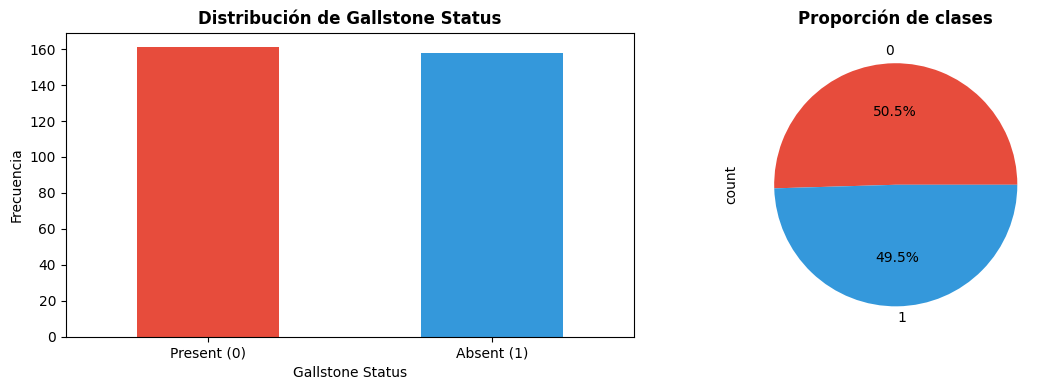

In [2]:
# Distribución de la variable objetivo
target_col = 'Gallstone Status'
print("Distribución de clases:")
print(df[target_col].value_counts())
print(f"\nProporción:")
print(df[target_col].value_counts(normalize=True))

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#3498db'])
ax[0].set_title('Distribución de Gallstone Status', fontweight='bold')
ax[0].set_xticklabels(['Present (0)', 'Absent (1)'], rotation=0)
ax[0].set_ylabel('Frecuencia')

df[target_col].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#e74c3c', '#3498db'])
ax[1].set_title('Proporción de clases', fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 variables correlacionadas con 'Gallstone Status':
Gallstone Status                                  1.000000
Vitamin D                                         0.354873
C-Reactive Protein (CRP)                          0.281995
Lean Mass (LM) (%)                                0.225749
Total Body Fat Ratio (TBFR) (%)                   0.225470
Bone Mass (BM)                                    0.216570
Hemoglobin (HGB)                                  0.196872
Extracellular Water (ECW)                         0.178436
Total Fat Content (TFC)                           0.170158
Extracellular Fluid/Total Body Water (ECF/TBW)    0.169826
Hyperlipidemia                                    0.161901
Name: Gallstone Status, dtype: float64

MATRIZ DE CORRELACIÓN COMPLETA


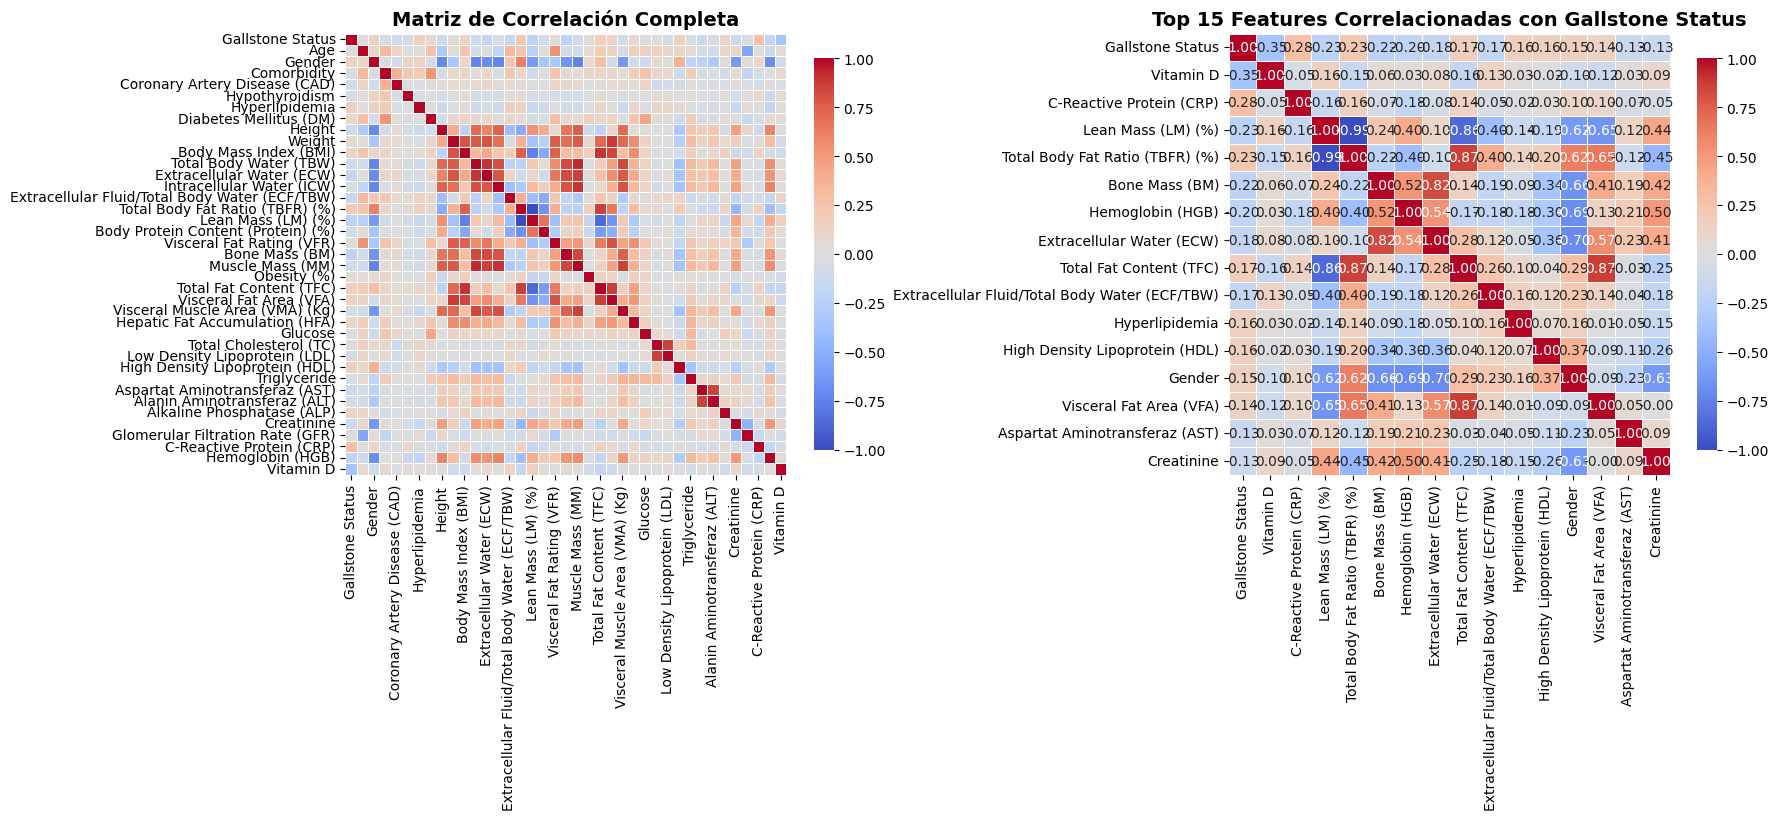

In [3]:
# Matriz de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

if target_col in numeric_cols:
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    print(f"Top 10 variables correlacionadas con '{target_col}':")
    print(target_corr.head(11))
    
    print('\n' + '='*60)
    print('MATRIZ DE CORRELACIÓN COMPLETA')
    print('='*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title('Matriz de Correlación Completa', fontsize=14, fontweight='bold')
    
    top_features = target_corr.head(16).index
    corr_top = df[top_features].corr()
    sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f'Top 15 Features Correlacionadas con {target_col}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 2.1 ANÁLISIS AVANZADO DE OUTLIERS

Detección de outliers usando IQR y Z-score para identificar valores atípicos en las features numéricas.

🔍 ANÁLISIS DE OUTLIERS - MÉTODO IQR (Interquartile Range)

Features con outliers (IQR):


,Feature,Outliers,Porcentaje
5,Diabetes Mellitus (DM),43,13.479624
28,C-Reactive Protein (CRP),34,10.658307
24,Alanin Aminotransferaz (ALT),27,8.463950
18,Glucose,25,7.836991
23,Aspartat Aminotransferaz (AST),23,7.210031
22,Triglyceride,20,6.269592
27,Glomerular Filtration Rate (GFR),13,4.075235
25,Alkaline Phosphatase (ALP),12,3.761755
2,Coronary Artery Disease (CAD),12,3.761755
3,Hypothyroidism,9,2.821317


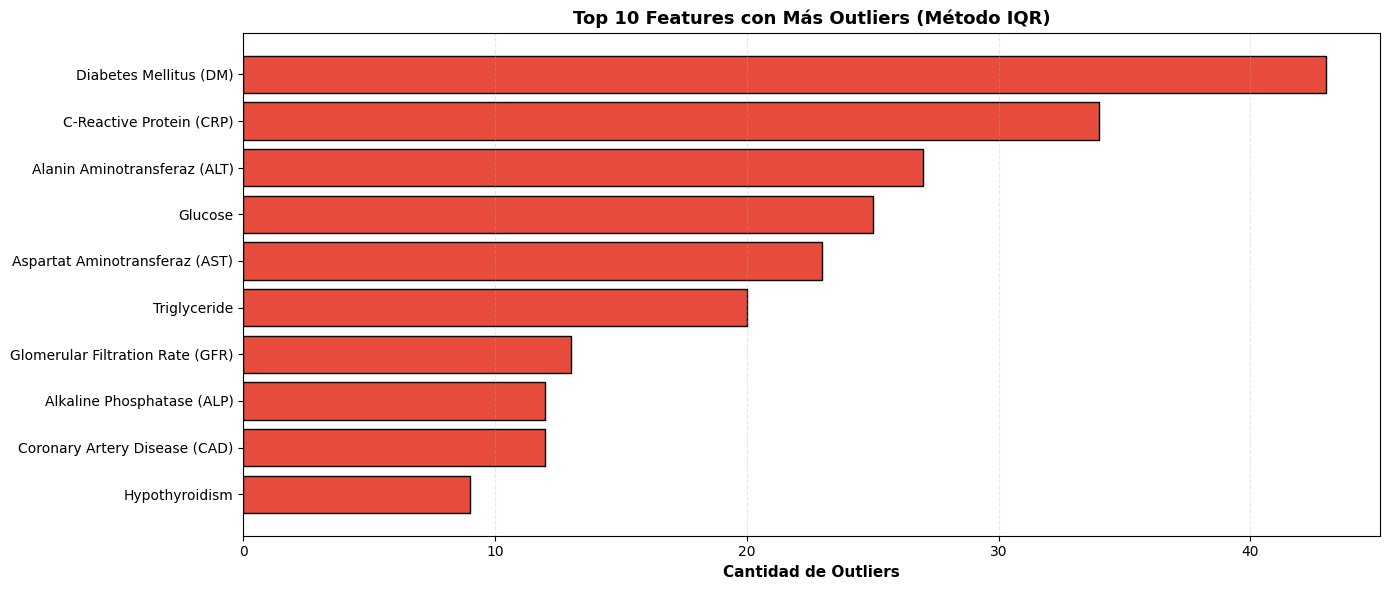


🔍 ANÁLISIS DE OUTLIERS - Z-SCORE (|Z| > 3)

Features con outliers (Z-score > 3):


,Feature,Outliers,Porcentaje
2,Coronary Artery Disease (CAD),12,3.761755
3,Hypothyroidism,9,2.821317
4,Hyperlipidemia,8,2.507837
27,C-Reactive Protein (CRP),7,2.194357
17,Glucose,7,2.194357
21,Triglyceride,5,1.567398
10,Extracellular Fluid/Total Body Water (ECF/TBW),4,1.253918
6,Body Mass Index (BMI),4,1.253918
26,Glomerular Filtration Rate (GFR),4,1.253918
16,Visceral Fat Area (VFA),4,1.253918



💡 Nota: Los outliers NO se eliminan, se mantienen para análisis clínico completo


In [4]:
from scipy import stats

print("="*100)
print("🔍 ANÁLISIS DE OUTLIERS - MÉTODO IQR (Interquartile Range)")
print("="*100)

# Método IQR
outliers_count = {}
for col in numeric_cols:
    if col != target_col:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count[col] = outliers

outliers_df = pd.DataFrame(list(outliers_count.items()), columns=['Feature', 'Outliers'])
outliers_df = outliers_df.sort_values('Outliers', ascending=False)
outliers_df['Porcentaje'] = (outliers_df['Outliers'] / len(df)) * 100

print(f"\nFeatures con outliers (IQR):")
display(outliers_df.head(10))

# Visualización
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(outliers_df.head(10)['Feature'], outliers_df.head(10)['Outliers'], color='#e74c3c', edgecolor='black')
ax.set_xlabel('Cantidad de Outliers', fontweight='bold', fontsize=11)
ax.set_title('Top 10 Features con Más Outliers (Método IQR)', fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("🔍 ANÁLISIS DE OUTLIERS - Z-SCORE (|Z| > 3)")
print("="*100)

# Z-score
z_outliers = {}
for col in numeric_cols:
    if col != target_col:
        z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
        outliers = (z_scores > 3).sum()
        if outliers > 0:
            z_outliers[col] = outliers

z_outliers_df = pd.DataFrame(list(z_outliers.items()), columns=['Feature', 'Outliers'])
z_outliers_df = z_outliers_df.sort_values('Outliers', ascending=False)
z_outliers_df['Porcentaje'] = (z_outliers_df['Outliers'] / len(df)) * 100

print(f"\nFeatures con outliers (Z-score > 3):")
display(z_outliers_df.head(10))

print("\n💡 Nota: Los outliers NO se eliminan, se mantienen para análisis clínico completo")

## 2.2 TESTS ESTADÍSTICOS - DIFERENCIAS ENTRE CLASES

Evaluamos si existen diferencias estadísticamente significativas entre las clases usando t-test y Mann-Whitney.

📊 TESTS DE HIPÓTESIS - DIFERENCIAS ENTRE CLASES

Clase 0 (Present): 161 muestras
Clase 1 (Absent): 158 muestras

Top 10 Features con Mayor Diferencia Estadística (Mann-Whitney p-value):


,Feature,Mann-Whitney p-value,T-test p-value,Mean Class 0,Mean Class 1,Significativo (p<0.05)
11,Extracellular Water (ECW),0.001313,0.001391,17.629193,16.502532,✅
5,Hyperlipidemia,0.003916,0.004349,0.000000,0.050633,✅
1,Gender,0.006213,0.006020,0.416149,0.569620,✅
13,Extracellular Fluid/Total Body Water (ECF/TBW),0.017979,0.002408,42.757019,41.656709,✅
9,Body Mass Index (BMI),0.030813,0.030024,28.238509,29.527848,✅
7,Height,0.030990,0.054270,168.229814,166.063291,✅
10,Total Body Water (TBW),0.061087,0.047183,41.460248,39.698734,✅
6,Diabetes Mellitus (DM),0.062062,0.062425,0.099379,0.170886,❌
3,Coronary Artery Disease (CAD),0.084009,0.082504,0.055901,0.018987,❌
4,Hypothyroidism,0.326015,0.324372,0.037267,0.018987,❌


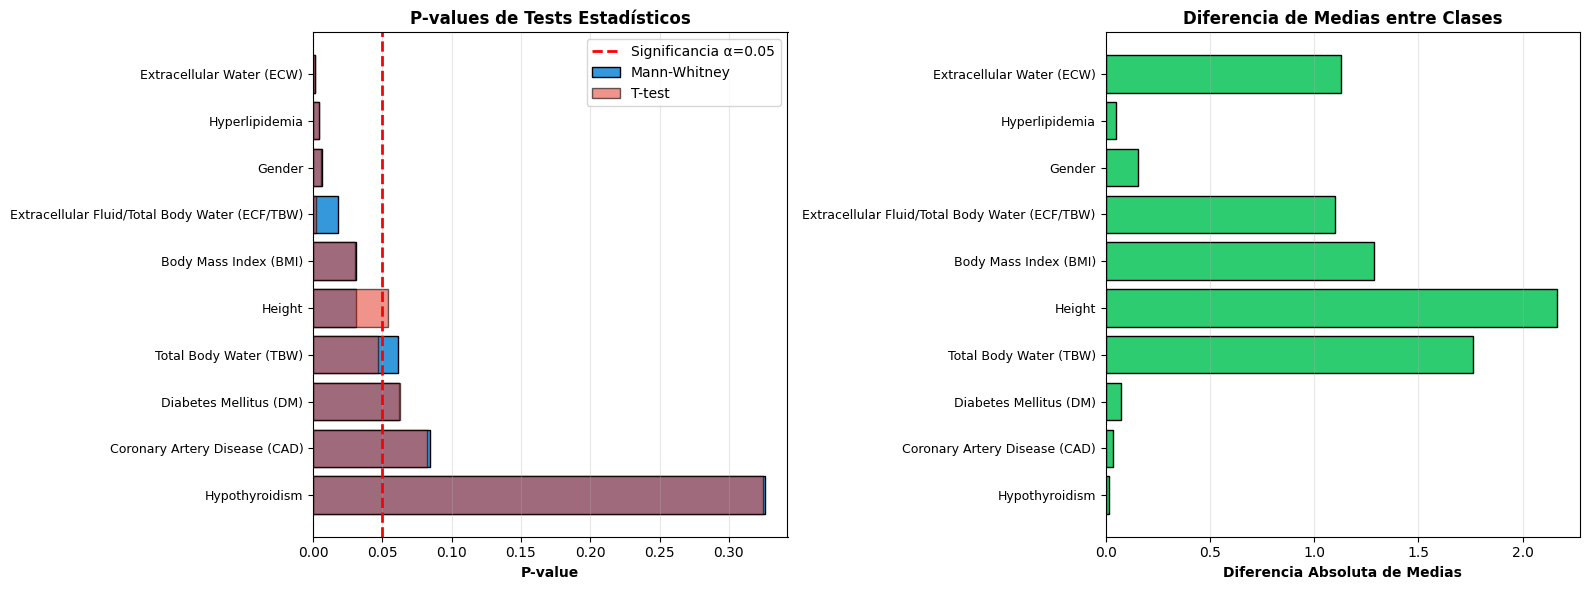


📊 RESUMEN:
  • Features con diferencias significativas (p<0.05): 6/14
  • Porcentaje: 42.9%


In [5]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

print("="*100)
print("📊 TESTS DE HIPÓTESIS - DIFERENCIAS ENTRE CLASES")
print("="*100)

# Separar datos por clase
class_0 = df[df[target_col] == 0]
class_1 = df[df[target_col] == 1]

print(f"\nClase 0 (Present): {len(class_0)} muestras")
print(f"Clase 1 (Absent): {len(class_1)} muestras\n")

# Tests estadísticos
statistical_tests = []

for col in numeric_cols[:15]:  # Top 15 features para evitar saturación
    if col != target_col:
        data_0 = class_0[col].dropna()
        data_1 = class_1[col].dropna()
        
        # T-test (asume normalidad)
        t_stat, t_pval = ttest_ind(data_0, data_1, equal_var=False)
        
        # Mann-Whitney (no paramétrico)
        u_stat, u_pval = mannwhitneyu(data_0, data_1, alternative='two-sided')
        
        # Test de normalidad (Shapiro-Wilk) - muestra pequeña de 50
        _, shapiro_pval_0 = shapiro(data_0.sample(min(50, len(data_0)), random_state=SEED))
        _, shapiro_pval_1 = shapiro(data_1.sample(min(50, len(data_1)), random_state=SEED))
        
        statistical_tests.append({
            'Feature': col,
            'T-test p-value': t_pval,
            'Mann-Whitney p-value': u_pval,
            'Shapiro Class 0': shapiro_pval_0,
            'Shapiro Class 1': shapiro_pval_1,
            'Mean Class 0': data_0.mean(),
            'Mean Class 1': data_1.mean(),
            'Significativo (p<0.05)': '✅' if min(t_pval, u_pval) < 0.05 else '❌'
        })

stats_df = pd.DataFrame(statistical_tests)
stats_df = stats_df.sort_values('Mann-Whitney p-value')

print("Top 10 Features con Mayor Diferencia Estadística (Mann-Whitney p-value):")
display(stats_df[['Feature', 'Mann-Whitney p-value', 'T-test p-value', 
                  'Mean Class 0', 'Mean Class 1', 'Significativo (p<0.05)']].head(10))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# P-values
top_features = stats_df.head(10)
axes[0].barh(range(len(top_features)), top_features['Mann-Whitney p-value'], 
             color='#3498db', edgecolor='black', label='Mann-Whitney')
axes[0].barh(range(len(top_features)), top_features['T-test p-value'], 
             color='#e74c3c', alpha=0.6, edgecolor='black', label='T-test')
axes[0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significancia α=0.05')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'], fontsize=9)
axes[0].set_xlabel('P-value', fontweight='bold')
axes[0].set_title('P-values de Tests Estadísticos', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Diferencia de medias
mean_diff = np.abs(top_features['Mean Class 0'] - top_features['Mean Class 1'])
axes[1].barh(range(len(top_features)), mean_diff, color='#2ecc71', edgecolor='black')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['Feature'], fontsize=9)
axes[1].set_xlabel('Diferencia Absoluta de Medias', fontweight='bold')
axes[1].set_title('Diferencia de Medias entre Clases', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

significant_count = (stats_df['Mann-Whitney p-value'] < 0.05).sum()
print(f"\n📊 RESUMEN:")
print(f"  • Features con diferencias significativas (p<0.05): {significant_count}/{len(stats_df)}")
print(f"  • Porcentaje: {significant_count/len(stats_df)*100:.1f}%")

## 2.3 BOXPLOTS POR CLASE

Visualización de la distribución de las principales features separadas por clase.

📦 BOXPLOTS - DISTRIBUCIÓN POR CLASE

Visualizando top 12 features más correlacionadas con Gallstone Status



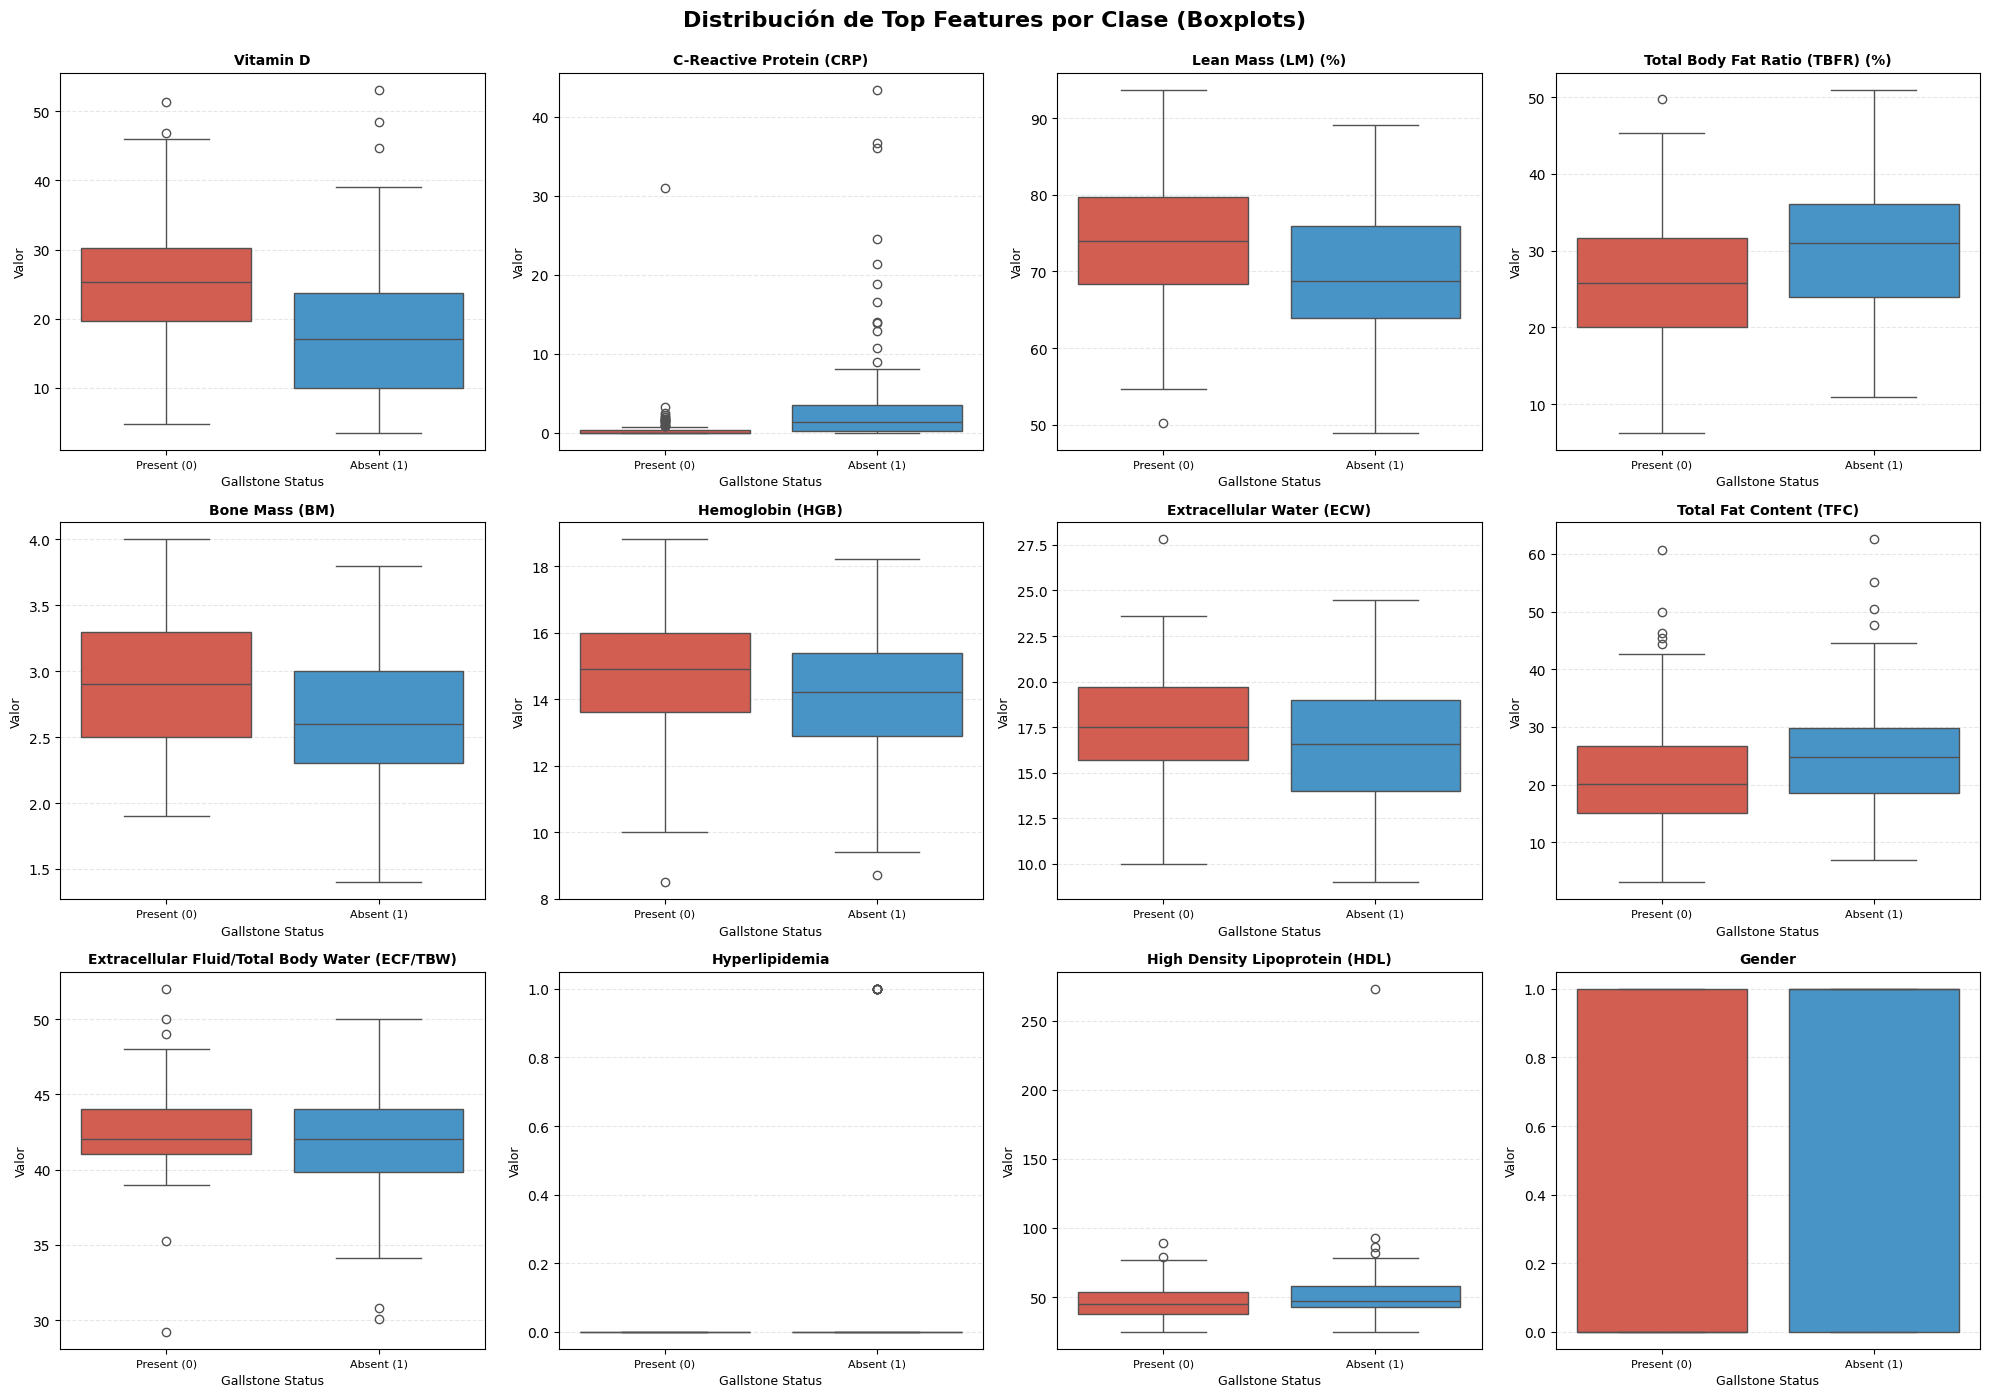

✅ Boxplots generados exitosamente


In [7]:
# Seleccionar top 12 features más correlacionadas
if target_col in numeric_cols:
    top_corr_features = corr_matrix[target_col].abs().sort_values(ascending=False)[1:13].index.tolist()
    
    print("="*100)
    print("📦 BOXPLOTS - DISTRIBUCIÓN POR CLASE")
    print("="*100)
    print(f"\nVisualizando top 12 features más correlacionadas con {target_col}\n")
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_corr_features):
        # Convertir target_col a string para consistencia con palette
        sns.boxplot(data=df, x=target_col, y=feature, ax=axes[idx], 
                   palette={'0': '#e74c3c', '1': '#3498db'})  # Claves como strings
        axes[idx].set_title(feature, fontweight='bold', fontsize=10)
        axes[idx].set_xlabel('Gallstone Status', fontsize=9)
        axes[idx].set_ylabel('Valor', fontsize=9)
        axes[idx].set_xticklabels(['Present (0)', 'Absent (1)'], fontsize=8)
        axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.suptitle('Distribución de Top Features por Clase (Boxplots)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print("✅ Boxplots generados exitosamente")

## 2.4 PAIR PLOTS - TOP FEATURES

Visualización de relaciones entre las principales features usando pair plots coloreados por clase.

🔗 PAIR PLOTS - RELACIONES ENTRE TOP FEATURES

Visualizando top 5 features:
['Vitamin D', 'C-Reactive Protein (CRP)', 'Lean Mass (LM) (%)', 'Total Body Fat Ratio (TBFR) (%)', 'Bone Mass (BM)']



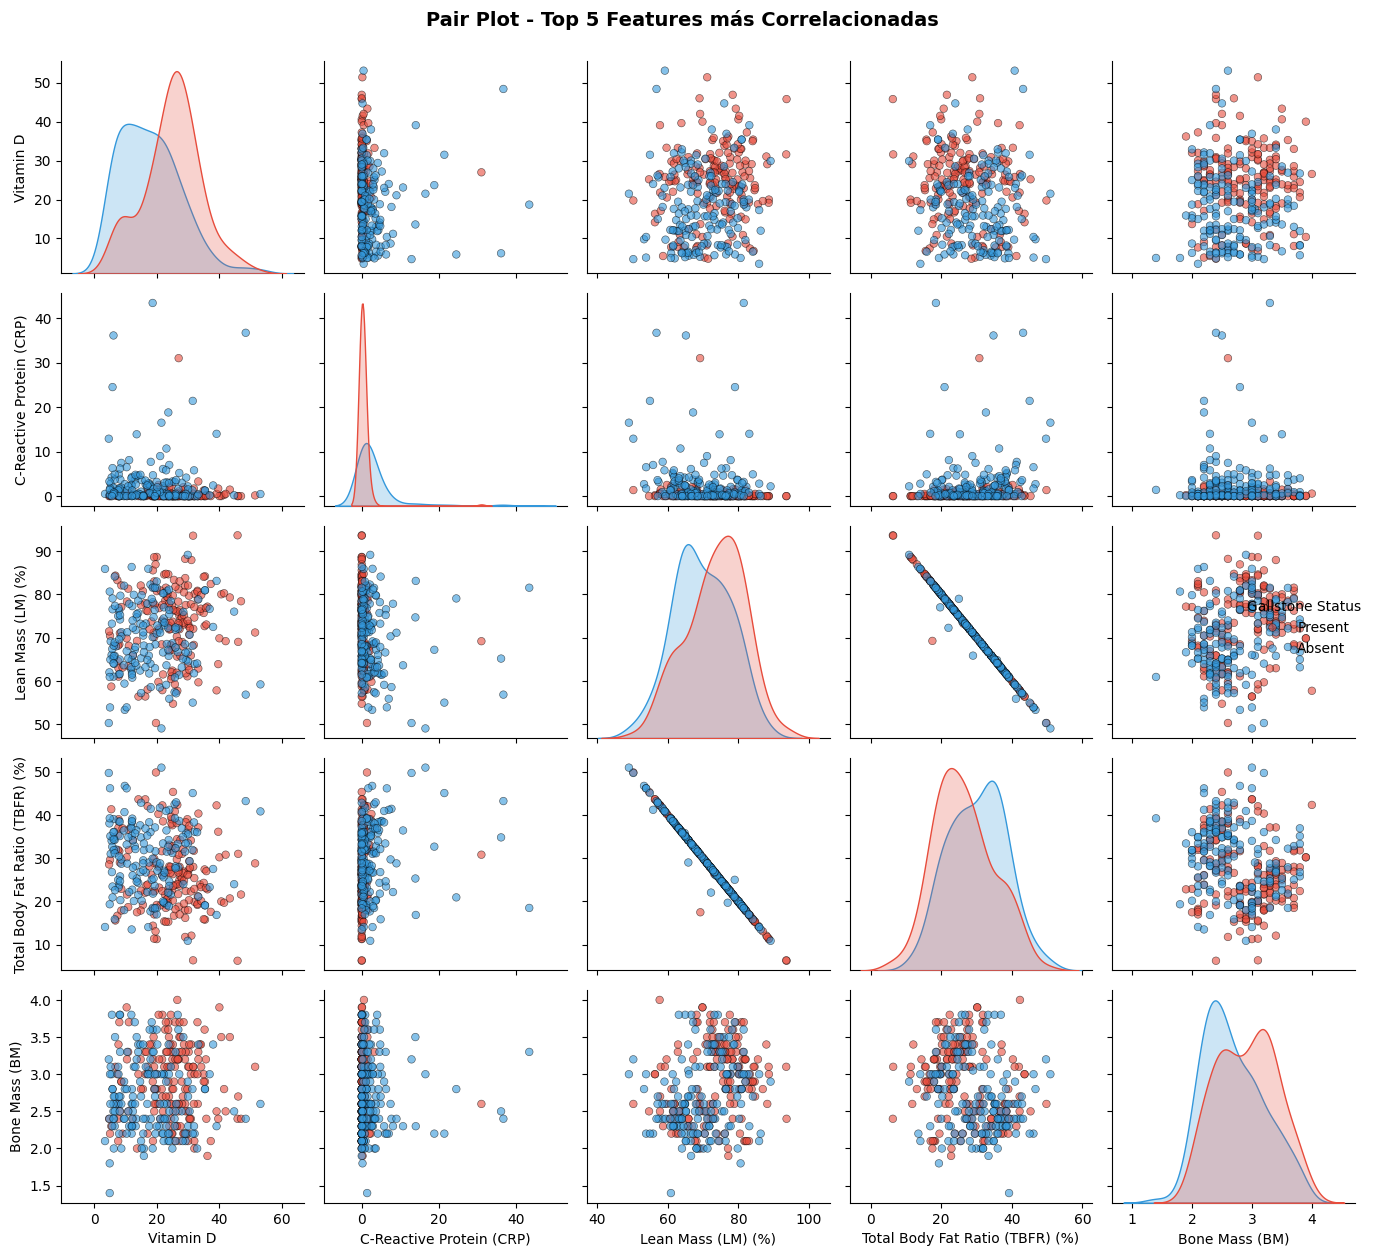

✅ Pair plot generado exitosamente


In [8]:
# Pair plot de top 5 features (para no saturar)
if target_col in numeric_cols:
    top_5_features = corr_matrix[target_col].abs().sort_values(ascending=False)[1:6].index.tolist()
    
    print("="*100)
    print("🔗 PAIR PLOTS - RELACIONES ENTRE TOP FEATURES")
    print("="*100)
    print(f"\nVisualizando top 5 features:\n{top_5_features}\n")
    
    # Crear subset
    pair_df = df[top_5_features + [target_col]].copy()
    pair_df[target_col] = pair_df[target_col].map({0: 'Present', 1: 'Absent'})
    
    # Pair plot
    pair_plot = sns.pairplot(pair_df, hue=target_col, palette={'Present': '#e74c3c', 'Absent': '#3498db'},
                             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'},
                             height=2.5, aspect=1.0)
    
    pair_plot.fig.suptitle('Pair Plot - Top 5 Features más Correlacionadas', 
                          fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.show()
    
    print("✅ Pair plot generado exitosamente")

## 3. ELIMINACIÓN DE FEATURES REDUNDANTES

Eliminamos features con alta colinealidad para reducir multicolinealidad.

In [9]:
drop_cols = [
    "Visceral Fat Area (VFA)",
    "Total Fat Content (TFC)",
    "Lean Mass (LM) (%)",
    "Extracellular Water (ECW)",
    "Intracellular Water (ICW)",
    "Visceral Muscle Area (VMA) (Kg)",
    "Total Cholesterol (TC)",
    "Aspartat Aminotransferaz (AST)",
    "Total Body Water (TBW)",
    "Bone Mass (BM)"
]

drop_cols_found = [c for c in drop_cols if c in df.columns]
print(f"Eliminando {len(drop_cols_found)} features redundantes...")

df = df.drop(columns=drop_cols_found)
print(f"✓ Nueva forma: {df.shape}")

Eliminando 10 features redundantes...
✓ Nueva forma: (319, 29)


## 4. PREPROCESAMIENTO Y DIVISIÓN DE DATOS

División estratificada: Train (70%), Validation (15%), Test (15%).

In [10]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Separar features y target
X = df.drop(columns=[target_col])
y = df[target_col]

# División estratificada: Train (70%), Validation (15%), Test (15%)
# ⚠️ IMPORTANTE: SMOTE solo se aplica en train, NUNCA en val/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

print("="*100)
print("✂️ DIVISIÓN ESTRATIFICADA DE DATOS")
print("="*100)
print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribución Train: {dict(Counter(y_train))}")
print(f"Distribución Val:   {dict(Counter(y_val))}")
print(f"Distribución Test:  {dict(Counter(y_test))}")
print("\n⚠️ NOTA: Val y Test mantienen la distribución real (NO se aplica SMOTE)")
print("="*100)

✂️ DIVISIÓN ESTRATIFICADA DE DATOS
Train: 223 muestras (69.9%)
Val:   48 muestras (15.0%)
Test:  48 muestras (15.0%)

Distribución Train: {0: 113, 1: 110}
Distribución Val:   {1: 24, 0: 24}
Distribución Test:  {1: 24, 0: 24}

⚠️ NOTA: Val y Test mantienen la distribución real (NO se aplica SMOTE)


## 5. COMPARACIÓN DE TÉCNICAS DE BALANCEO (SMOTE vs Borderline-SMOTE vs ADASYN)

Evaluamos diferentes estrategias de balanceo de clases en el conjunto de entrenamiento.

In [11]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score

print("="*100)
print("⚖️ COMPARACIÓN DE TÉCNICAS DE BALANCEO")
print("="*100)
print(f"ANTES de balanceo: {dict(Counter(y_train))}")

# Primero escalamos los datos de train
scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)

# Probar diferentes técnicas
balancing_methods = {
    'SMOTE': SMOTE(random_state=SEED, k_neighbors=5),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=SEED, k_neighbors=5),
    'ADASYN': ADASYN(random_state=SEED, n_neighbors=5)
}

balancing_results = []

for method_name, sampler in balancing_methods.items():
    print(f"\n{'─'*90}")
    print(f"🔄 Probando: {method_name}")
    
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)
        print(f"   DESPUÉS: {dict(Counter(y_resampled))} | +{len(y_resampled) - len(y_train)} muestras")
        
        # Entrenar modelo rápido para evaluar
        quick_model = LogisticRegression(random_state=SEED, max_iter=1000)
        quick_model.fit(X_resampled, y_resampled)
        
        # Evaluar en validation (escalado por separado)
        X_val_scaled = scaler_temp.transform(X_val)
        y_val_pred = quick_model.predict(X_val_scaled)
        
        val_f1 = f1_score(y_val, y_val_pred, average='weighted')
        val_recall = recall_score(y_val, y_val_pred, average='weighted')
        
        balancing_results.append({
            'Método': method_name,
            'Muestras Generadas': len(y_resampled) - len(y_train),
            'Val F1-Score': val_f1,
            'Val Recall': val_recall
        })
        
        print(f"   Val F1: {val_f1:.4f} | Val Recall: {val_recall:.4f}")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        continue

print(f"\n{'='*100}")
print("📊 RESUMEN DE COMPARACIÓN")
print(f"{'='*100}")
balancing_df = pd.DataFrame(balancing_results)
display(balancing_df)

best_method = balancing_df.loc[balancing_df['Val Recall'].idxmax(), 'Método']
print(f"\n🏆 Mejor método por Recall: {best_method}")
print("💡 Se utilizará esta técnica para el entrenamiento final")
print("="*100)

⚖️ COMPARACIÓN DE TÉCNICAS DE BALANCEO
ANTES de balanceo: {0: 113, 1: 110}

──────────────────────────────────────────────────────────────────────────────────────────
🔄 Probando: SMOTE
   DESPUÉS: {0: 113, 1: 113} | +3 muestras
   Val F1: 0.7078 | Val Recall: 0.7083

──────────────────────────────────────────────────────────────────────────────────────────
🔄 Probando: Borderline-SMOTE
   DESPUÉS: {0: 113, 1: 113} | +3 muestras
   Val F1: 0.7078 | Val Recall: 0.7083

──────────────────────────────────────────────────────────────────────────────────────────
🔄 Probando: ADASYN
   ❌ Error: No samples will be generated with the provided ratio settings.

📊 RESUMEN DE COMPARACIÓN
   DESPUÉS: {0: 113, 1: 113} | +3 muestras
   Val F1: 0.7078 | Val Recall: 0.7083

──────────────────────────────────────────────────────────────────────────────────────────
🔄 Probando: Borderline-SMOTE
   DESPUÉS: {0: 113, 1: 113} | +3 muestras
   Val F1: 0.7078 | Val Recall: 0.7083

────────────────────────────────

,Método,Muestras Generadas,Val F1-Score,Val Recall
0,SMOTE,3,0.707826,0.708333
1,Borderline-SMOTE,3,0.707826,0.708333



🏆 Mejor método por Recall: SMOTE
💡 Se utilizará esta técnica para el entrenamiento final


## 6. PIPELINE DE MACHINE LEARNING (sin data leakage)

Implementación de Pipeline completo: Escalado → Feature Engineering → Modelo.
SMOTE se aplica dentro del loop de entrenamiento, NUNCA antes.

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

print("="*100)
print("🔧 CREACIÓN DE TRANSFORMADORES PERSONALIZADOS PARA PIPELINE")
print("="*100)

# Transformador de Feature Engineering
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.new_feature_names = None
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names)
        
        # 1. BMI × Age
        if 'Body Mass Index (BMI)' in X_df.columns and 'Age' in X_df.columns:
            X_df['BMI_x_Age'] = X_df['Body Mass Index (BMI)'] * X_df['Age']
        
        # 2. HDL/LDL ratio
        if 'High Density Lipoprotein (HDL)' in X_df.columns and 'Low Density Lipoprotein (LDL)' in X_df.columns:
            X_df['HDL_LDL_ratio'] = X_df['High Density Lipoprotein (HDL)'] / (X_df['Low Density Lipoprotein (LDL)'] + 1e-5)
        
        # 3. Fat Index
        if 'Body Mass Index (BMI)' in X_df.columns and 'Skeletal Muscle Mass (SMM)' in X_df.columns:
            X_df['Fat_Index'] = X_df['Body Mass Index (BMI)'] / (X_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
        
        # 4. Age²
        if 'Age' in X_df.columns:
            X_df['Age_squared'] = X_df['Age'] ** 2
        
        # 5. TG/HDL ratio
        if 'Triglyceride (TG)' in X_df.columns and 'High Density Lipoprotein (HDL)' in X_df.columns:
            X_df['TG_HDL_ratio'] = X_df['Triglyceride (TG)'] / (X_df['High Density Lipoprotein (HDL)'] + 1e-5)
        
        # 6. Liver Enzyme Index
        if 'Alanine Aminotransferase (ALT)' in X_df.columns and 'Gamma-glutamyltransferase (GGT)' in X_df.columns:
            X_df['Liver_Enzyme_Index'] = X_df['Alanine Aminotransferase (ALT)'] * X_df['Gamma-glutamyltransferase (GGT)']
        
        self.new_feature_names = X_df.columns.tolist()
        return X_df.values
    
    def get_feature_names_out(self, input_features=None):
        return self.new_feature_names if self.new_feature_names else self.feature_names

print("✅ FeatureEngineer creado")
print("   • BMI × Age")
print("   • HDL/LDL ratio")
print("   • Fat Index")
print("   • Age²")
print("   • TG/HDL ratio")
print("   • Liver Enzyme Index")

# Aplicar mejor técnica de balanceo seleccionada anteriormente
if best_method == 'SMOTE':
    best_sampler = SMOTE(random_state=SEED, k_neighbors=5)
elif best_method == 'Borderline-SMOTE':
    best_sampler = BorderlineSMOTE(random_state=SEED, k_neighbors=5)
else:  # ADASYN
    best_sampler = ADASYN(random_state=SEED, n_neighbors=5)

print(f"\n✅ Técnica de balanceo seleccionada: {best_method}")
print("="*100)

🔧 CREACIÓN DE TRANSFORMADORES PERSONALIZADOS PARA PIPELINE
✅ FeatureEngineer creado
   • BMI × Age
   • HDL/LDL ratio
   • Fat Index
   • Age²
   • TG/HDL ratio
   • Liver Enzyme Index

✅ Técnica de balanceo seleccionada: SMOTE


## 7. ENTRENAMIENTO DE MODELOS CON PIPELINE (Priorizando Recall)

Entrenamiento con Pipeline completo y optimización enfocada en Recall (FN críticos).

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix, fbeta_score, roc_curve)
import time

print("="*100)
print("🤖 ENTRENAMIENTO DE MODELOS CON PIPELINE")
print("="*100)
print("⚠️ PRIORIDAD: Recall (minimizar Falsos Negativos - FN críticos)")
print("="*100)

# Crear Pipeline base
def create_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('feature_engineer', FeatureEngineer(X_train.columns.tolist())),
        ('model', model)
    ])

# Definir modelos con parámetros ajustados (max_depth reducido para Decision Tree)
models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED, max_depth=5, class_weight='balanced'),  # Reducido de 10 a 5
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss', n_jobs=-1, scale_pos_weight=2),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1, n_jobs=-1, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', C=10, probability=True, random_state=SEED, class_weight='balanced'),  # C ajustado
    'KNN': KNeighborsClassifier(n_neighbors=7),  # Ajustado de 5 a 7
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=SEED)
}

results = []
roc_curves_data = {}

print(f"\n🔄 Aplicando {best_method} solo en train...")
X_train_balanced, y_train_balanced = best_sampler.fit_resample(X_train, y_train)
print(f"✅ Train balanceado: {dict(Counter(y_train_balanced))}")
print(f"   Val sin modificar: {dict(Counter(y_val))}")
print(f"   Test sin modificar: {dict(Counter(y_test))}\n")

for name, model in models.items():
    print(f"{'─'*90}")
    print(f"📊 Entrenando: {name}")
    
    start_time = time.time()
    
    # Crear pipeline
    pipeline = create_pipeline(model)
    
    # Entrenar con datos balanceados
    pipeline.fit(X_train_balanced, y_train_balanced)
    train_time = time.time() - start_time
    
    # Predicciones
    y_train_pred = pipeline.predict(X_train_balanced)
    y_val_pred = pipeline.predict(X_val)
    
    # Probabilidades para ROC
    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_proba)
        fpr, tpr, _ = roc_curve(y_val, y_val_proba)
        roc_curves_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': val_auc}
    else:
        y_val_proba = None
        val_auc = None
    
    # Métricas en train
    train_acc = accuracy_score(y_train_balanced, y_train_pred)
    train_recall = recall_score(y_train_balanced, y_train_pred, average='weighted')
    
    # Métricas en validation
    val_acc = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    val_f2 = fbeta_score(y_val, y_val_pred, beta=2, average='weighted')  # F2 prioriza recall
    
    # Confusion matrix para FN
    cm = confusion_matrix(y_val, y_val_pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Train_Recall': train_recall,
        'Val_Acc': val_acc,
        'Val_Precision': val_precision,
        'Val_Recall': val_recall,
        'Val_F1': val_f1,
        'Val_F2': val_f2,
        'Val_AUC': val_auc,
        'FN': fn,
        'FP': fp,
        'Train_Time': train_time,
        'Pipeline': pipeline
    })
    
    print(f"  Train → Acc: {train_acc:.4f} | Recall: {train_recall:.4f}")
    print(f"  Val   → Acc: {val_acc:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f} | F2: {val_f2:.4f}")
    print(f"  Confusion Matrix → FN: {fn} (críticos) | FP: {fp}")
    if val_auc:
        print(f"  AUC-ROC: {val_auc:.4f}")
    print(f"  Tiempo: {train_time:.2f}s")

# Ordenar por F2-Score (prioriza recall)
results_df = pd.DataFrame(results).sort_values('Val_F2', ascending=False)

print("\n" + "="*100)
print("📊 RESUMEN DE RESULTADOS (ordenado por Val F2-Score - prioriza Recall)")
print("="*100)
display(results_df[['Model', 'Val_Recall', 'Val_F1', 'Val_F2', 'Val_AUC', 'FN', 'FP', 'Train_Time']])

best_model_name = results_df.iloc[0]['Model']
best_pipeline = results_df.iloc[0]['Pipeline']
print(f"\n🏆 Mejor modelo: {best_model_name}")
print(f"   Val F2-Score: {results_df.iloc[0]['Val_F2']:.4f}")
print(f"   Val Recall: {results_df.iloc[0]['Val_Recall']:.4f}")
print(f"   Falsos Negativos: {results_df.iloc[0]['FN']}")
print("="*100)

🤖 ENTRENAMIENTO DE MODELOS CON PIPELINE
⚠️ PRIORIDAD: Recall (minimizar Falsos Negativos - FN críticos)

🔄 Aplicando SMOTE solo en train...
✅ Train balanceado: {0: 113, 1: 113}
   Val sin modificar: {1: 24, 0: 24}
   Test sin modificar: {1: 24, 0: 24}

──────────────────────────────────────────────────────────────────────────────────────────
📊 Entrenando: Logistic Regression
  Train → Acc: 0.8805 | Recall: 0.8805
  Val   → Acc: 0.6875 | Recall: 0.6875 | F1: 0.6863 | F2: 0.6864
  Confusion Matrix → FN: 9 (críticos) | FP: 6
  AUC-ROC: 0.7882
  Tiempo: 0.03s
──────────────────────────────────────────────────────────────────────────────────────────
📊 Entrenando: Decision Tree
  Train → Acc: 0.9336 | Recall: 0.9336
  Val   → Acc: 0.7292 | Recall: 0.7292 | F1: 0.7281 | F2: 0.7281
  Confusion Matrix → FN: 8 (críticos) | FP: 5
  AUC-ROC: 0.7517
  Tiempo: 0.00s
──────────────────────────────────────────────────────────────────────────────────────────
📊 Entrenando: Random Forest
  Train → Acc: 1

,Model,Val_Recall,Val_F1,Val_F2,Val_AUC,FN,FP,Train_Time
4,XGBoost,0.770833,0.770734,0.770713,0.843750,5,6,0.531650
5,LightGBM,0.750000,0.750000,0.750000,0.845486,6,6,0.027001
2,Random Forest,0.729167,0.729049,0.729044,0.834201,6,7,0.114291
3,Gradient Boosting,0.729167,0.729049,0.729044,0.810764,7,6,0.144009
9,AdaBoost,0.729167,0.729049,0.729044,0.725694,7,6,0.119267
1,Decision Tree,0.729167,0.728105,0.728059,0.751736,8,5,0.004995
6,SVM,0.729167,0.726196,0.726087,0.755208,9,4,0.014000
0,Logistic Regression,0.687500,0.686275,0.686366,0.788194,9,6,0.031441
8,Naive Bayes,0.666667,0.644444,0.648148,0.792535,14,2,0.003007
7,KNN,0.625000,0.625000,0.625000,0.684896,9,9,0.004000



🏆 Mejor modelo: XGBoost
   Val F2-Score: 0.7707
   Val Recall: 0.7708
   Falsos Negativos: 5


## 8. VISUALIZACIÓN DE COMPARACIÓN DE MODELOS + CURVAS ROC

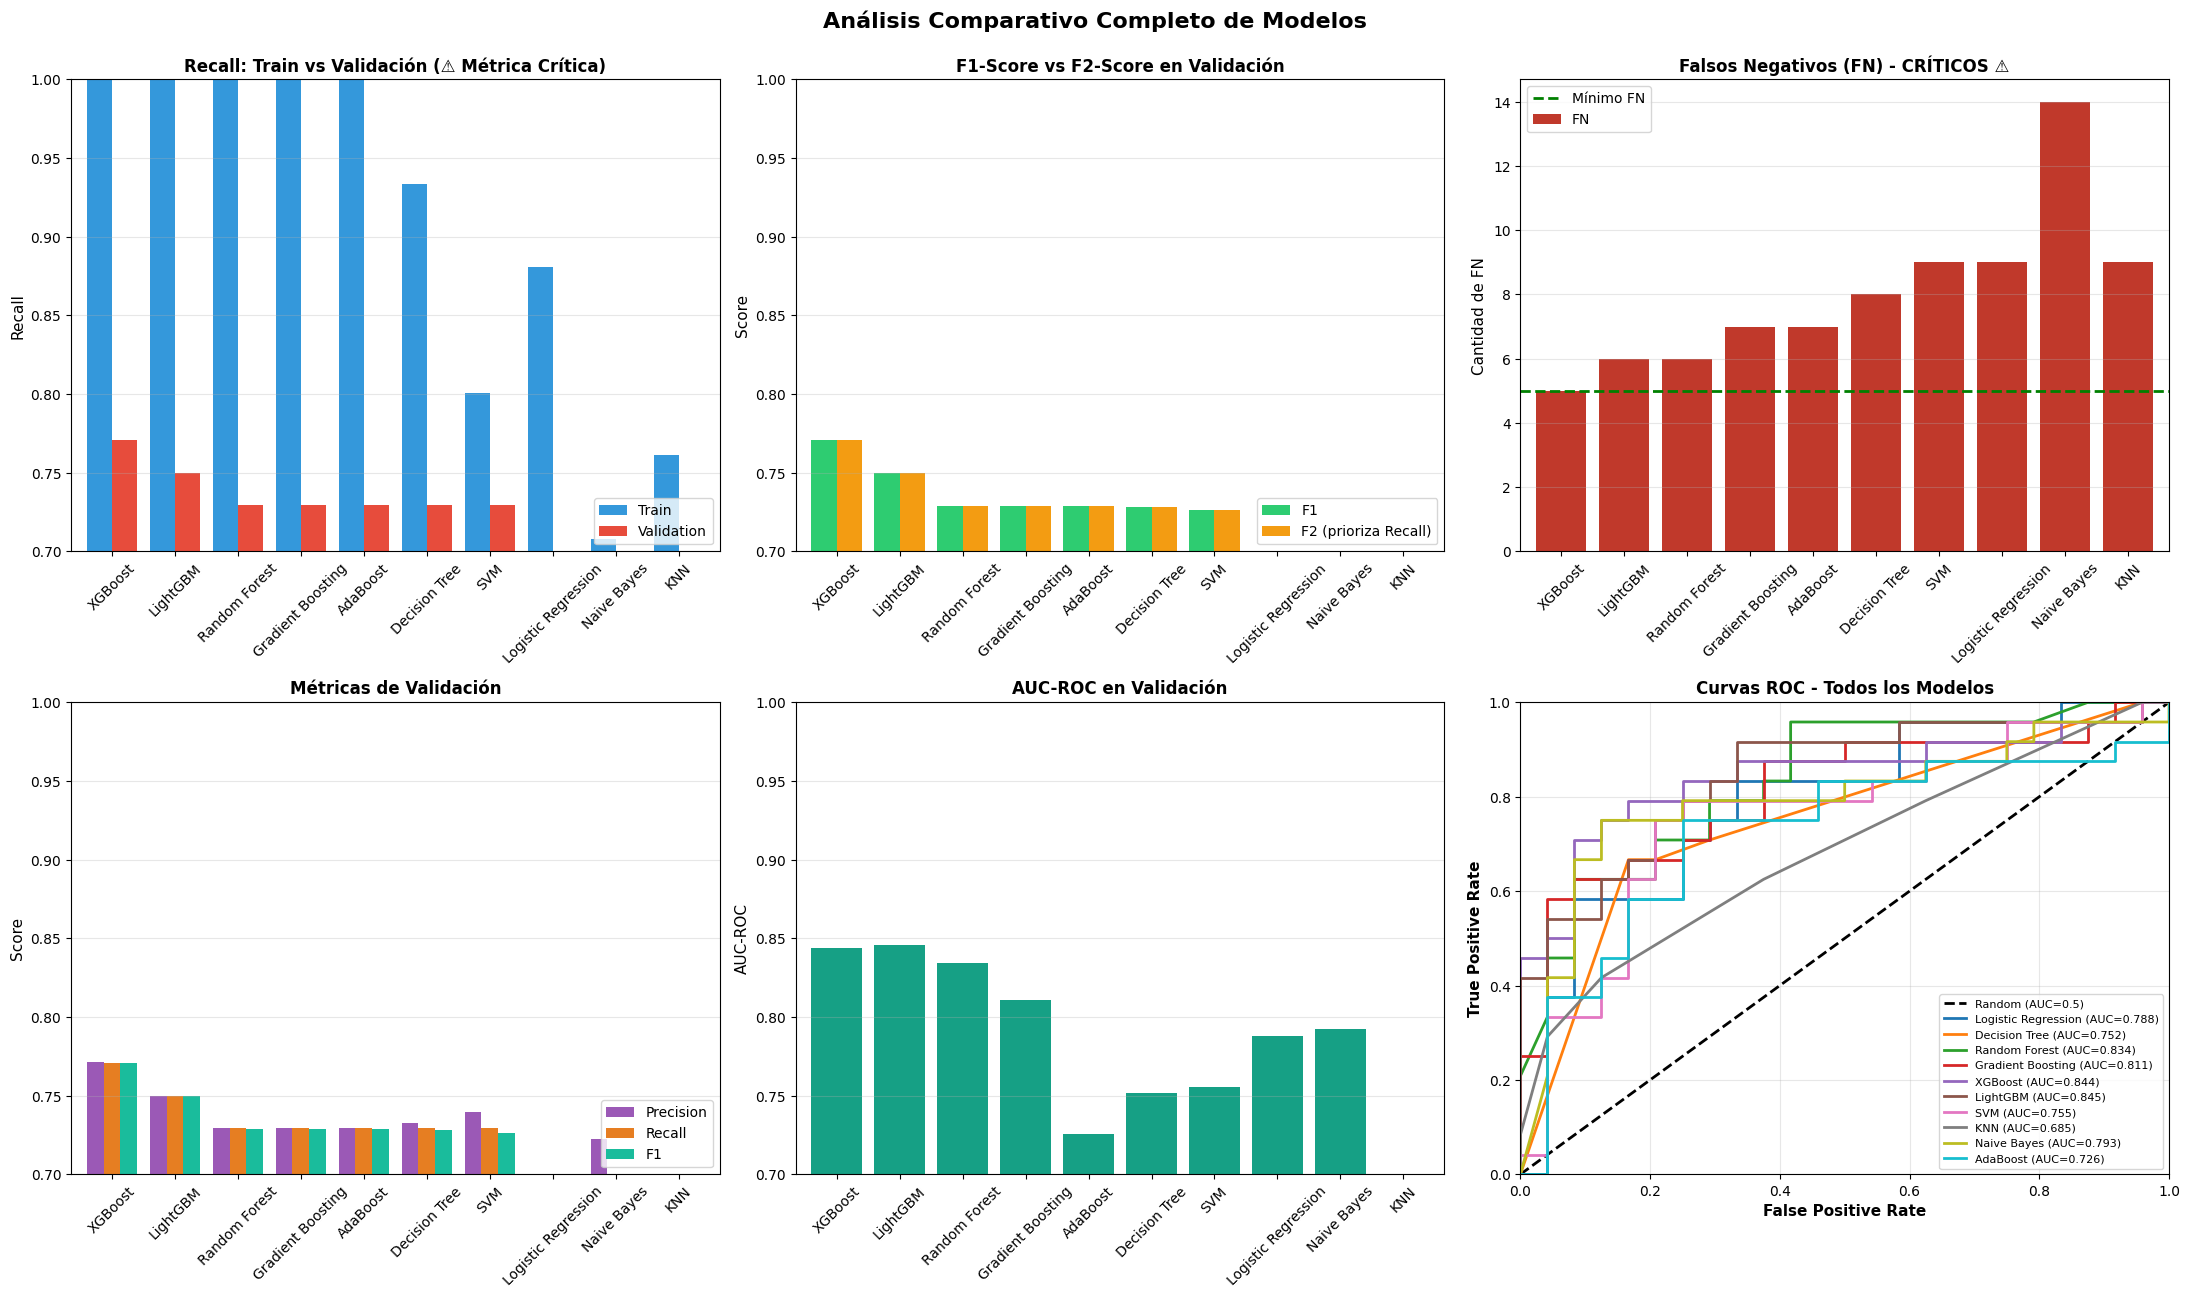


📊 Mejor modelo según Val F2-Score: XGBoost
   Val F2-Score: 0.7707
   Val Recall: 0.7708
   Falsos Negativos: 5


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# 1. Recall Comparison
results_df.plot(x='Model', y=['Train_Recall', 'Val_Recall'], kind='bar', ax=axes[0, 0], 
                color=['#3498db', '#e74c3c'], width=0.8)
axes[0, 0].set_title('Recall: Train vs Validación (⚠️ Métrica Crítica)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Recall', fontsize=11)
axes[0, 0].set_xlabel('')
axes[0, 0].legend(['Train', 'Validation'], loc='lower right')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.7, 1.0])

# 2. F1 vs F2-Score
results_df.plot(x='Model', y=['Val_F1', 'Val_F2'], kind='bar', ax=axes[0, 1], 
                color=['#2ecc71', '#f39c12'], width=0.8)
axes[0, 1].set_title('F1-Score vs F2-Score en Validación', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=11)
axes[0, 1].set_xlabel('')
axes[0, 1].legend(['F1', 'F2 (prioriza Recall)'], loc='lower right')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0.7, 1.0])

# 3. Falsos Negativos (CRÍTICO)
results_df.plot(x='Model', y='FN', kind='bar', ax=axes[0, 2], 
                color='#c0392b', width=0.8, legend=False)
axes[0, 2].set_title('Falsos Negativos (FN) - CRÍTICOS ⚠️', fontweight='bold', fontsize=12)
axes[0, 2].set_ylabel('Cantidad de FN', fontsize=11)
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)
axes[0, 2].axhline(y=results_df['FN'].min(), color='green', linestyle='--', linewidth=2, label='Mínimo FN')
axes[0, 2].legend()

# 4. Métricas de Validación
results_df.plot(x='Model', y=['Val_Precision', 'Val_Recall', 'Val_F1'], kind='bar', 
                ax=axes[1, 0], color=['#9b59b6', '#e67e22', '#1abc9c'], width=0.8)
axes[1, 0].set_title('Métricas de Validación', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_xlabel('')
axes[1, 0].legend(['Precision', 'Recall', 'F1'], loc='lower right')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0.7, 1.0])

# 5. AUC-ROC
auc_data = results_df[results_df['Val_AUC'].notna()].copy()
auc_data.plot(x='Model', y='Val_AUC', kind='bar', ax=axes[1, 1], 
              color='#16a085', width=0.8, legend=False)
axes[1, 1].set_title('AUC-ROC en Validación', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0.7, 1.0])

# 6. CURVAS ROC
axes[1, 2].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(roc_curves_data)))
for idx, (model_name, roc_data) in enumerate(roc_curves_data.items()):
    axes[1, 2].plot(roc_data['fpr'], roc_data['tpr'], 
                   linewidth=2, label=f"{model_name} (AUC={roc_data['auc']:.3f})",
                   color=colors_roc[idx])

axes[1, 2].set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
axes[1, 2].set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
axes[1, 2].set_title('Curvas ROC - Todos los Modelos', fontweight='bold', fontsize=12)
axes[1, 2].legend(loc='lower right', fontsize=8)
axes[1, 2].grid(alpha=0.3)
axes[1, 2].set_xlim([0, 1])
axes[1, 2].set_ylim([0, 1])

plt.suptitle('Análisis Comparativo Completo de Modelos', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📊 Mejor modelo según Val F2-Score:", results_df.iloc[0]['Model'])
print(f"   Val F2-Score: {results_df.iloc[0]['Val_F2']:.4f}")
print(f"   Val Recall: {results_df.iloc[0]['Val_Recall']:.4f}")
print(f"   Falsos Negativos: {results_df.iloc[0]['FN']}")

## 9. OPTIMIZACIÓN DE HIPERPARÁMETROS - TODOS LOS MODELOS TOP 3

Optimización exhaustiva con RandomizedSearchCV para los 3 mejores modelos, priorizando Recall.

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

print("="*100)
print("🎯 OPTIMIZACIÓN DE HIPERPARÁMETROS - TOP 3 MODELOS")
print("="*100)
print("⚠️ Métrica: Recall (priorizar detección de Gallstones)")
print("="*100)

# Definir grids para TODOS los modelos del top 3
top_3_models = results_df.head(3)

param_grids = {
    'Logistic Regression': {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['saga'],
        'model__class_weight': ['balanced', None],
        'model__max_iter': [1000, 2000]
    },
    'Decision Tree': {
        'model__max_depth': [3, 4, 5, 6, 7],  # Ajustado para dataset pequeño
        'model__min_samples_split': [2, 5, 10, 15],
        'model__min_samples_leaf': [1, 2, 4, 6],
        'model__criterion': ['gini', 'entropy'],
        'model__class_weight': ['balanced', None],
        'model__splitter': ['best', 'random']
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 10, 15, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None],
        'model__class_weight': ['balanced', 'balanced_subsample', None],
        'model__bootstrap': [True, False]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [3, 4, 5, 6],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__subsample': [0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 4, 5, 6],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.8, 0.9, 1.0],
        'model__min_child_weight': [1, 3, 5],
        'model__gamma': [0, 0.1, 0.2],
        'model__scale_pos_weight': [1, 2, 3]
    },
    'LightGBM': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 5, 7, -1],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__num_leaves': [15, 31, 50],
        'model__subsample': [0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.8, 0.9, 1.0],
        'model__min_child_samples': [10, 20, 30],
        'model__class_weight': ['balanced', None]
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 50, 100],
        'model__kernel': ['rbf', 'poly', 'sigmoid'],
        'model__gamma': ['scale', 'auto', 0.01, 0.1],
        'model__class_weight': ['balanced', None],
        'model__degree': [2, 3, 4]  # solo para poly
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan', 'minkowski'],
        'model__p': [1, 2]
    },
    'Naive Bayes': {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'AdaBoost': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.5, 1.0],
        'model__algorithm': ['SAMME', 'SAMME.R']
    }
}

# Scorer personalizado para Recall
recall_scorer = make_scorer(recall_score, average='weighted')

optimized_results = []

for idx, row in top_3_models.iterrows():
    model_name = row['Model']
    base_pipeline = row['Pipeline']
    
    print(f"\n{'='*90}")
    print(f"🔍 Optimizando: {model_name}")
    print(f"{'='*90}")
    print(f"F2-Score base: {row['Val_F2']:.4f} | Recall base: {row['Val_Recall']:.4f}")
    
    if model_name in param_grids:
        param_grid = param_grids[model_name]
        
        print(f"\nBúsqueda:")
        print(f"  • Método: RandomizedSearchCV")
        print(f"  • Iteraciones: 50")
        print(f"  • CV: 5-Fold Stratified")
        print(f"  • Métrica: Recall (weighted)")
        print(f"  • Parámetros a probar: {sum(len(v) if isinstance(v, list) else 1 for v in param_grid.values())}")
        
        search = RandomizedSearchCV(
            base_pipeline,
            param_grid,
            n_iter=50,
            cv=5,
            scoring=recall_scorer,
            n_jobs=-1,
            random_state=SEED,
            verbose=0
        )
        
        # Entrenar con datos balanceados
        search.fit(X_train_balanced, y_train_balanced)
        
        # Evaluar en validation
        y_val_pred_opt = search.best_estimator_.predict(X_val)
        
        val_recall_opt = recall_score(y_val, y_val_pred_opt, average='weighted')
        val_f1_opt = f1_score(y_val, y_val_pred_opt, average='weighted')
        val_f2_opt = fbeta_score(y_val, y_val_pred_opt, beta=2, average='weighted')
        
        cm_opt = confusion_matrix(y_val, y_val_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()
        
        if hasattr(search.best_estimator_.named_steps['model'], "predict_proba"):
            y_val_proba_opt = search.best_estimator_.predict_proba(X_val)[:, 1]
            val_auc_opt = roc_auc_score(y_val, y_val_proba_opt)
        else:
            val_auc_opt = None
        
        optimized_results.append({
            'Model': model_name,
            'Val_Recall_Base': row['Val_Recall'],
            'Val_Recall_Optimized': val_recall_opt,
            'Val_F2_Base': row['Val_F2'],
            'Val_F2_Optimized': val_f2_opt,
            'Val_AUC': val_auc_opt,
            'FN_Base': row['FN'],
            'FN_Optimized': fn_opt,
            'Best_Params': search.best_params_,
            'Best_Pipeline': search.best_estimator_,
            'CV_Best_Score': search.best_score_
        })
        
        print(f"\n✅ RESULTADOS:")
        print(f"  CV Recall (5-fold): {search.best_score_:.4f}")
        print(f"  Val Recall: {row['Val_Recall']:.4f} → {val_recall_opt:.4f} (Δ{val_recall_opt - row['Val_Recall']:+.4f})")
        print(f"  Val F2: {row['Val_F2']:.4f} → {val_f2_opt:.4f} (Δ{val_f2_opt - row['Val_F2']:+.4f})")
        print(f"  FN: {row['FN']} → {fn_opt} (Δ{fn_opt - row['FN']:+d})")
        
        print(f"\n📋 Mejores Parámetros:")
        for param, value in search.best_params_.items():
            print(f"  • {param}: {value}")
    
    else:
        print(f"⚠ Grid no definido para {model_name}, usando modelo base")
        optimized_results.append({
            'Model': model_name,
            'Val_Recall_Base': row['Val_Recall'],
            'Val_Recall_Optimized': row['Val_Recall'],
            'Val_F2_Base': row['Val_F2'],
            'Val_F2_Optimized': row['Val_F2'],
            'Val_AUC': row['Val_AUC'],
            'FN_Base': row['FN'],
            'FN_Optimized': row['FN'],
            'Best_Params': 'N/A',
            'Best_Pipeline': base_pipeline,
            'CV_Best_Score': row['Val_Recall']
        })

print("\n" + "="*100)
print("📊 COMPARACIÓN: ANTES vs DESPUÉS DE OPTIMIZACIÓN")
print("="*100)

opt_df = pd.DataFrame(optimized_results)
display(opt_df[['Model', 'Val_Recall_Base', 'Val_Recall_Optimized', 
                'Val_F2_Base', 'Val_F2_Optimized', 'FN_Base', 'FN_Optimized']])

# Seleccionar el mejor modelo optimizado
best_opt_idx = opt_df['Val_Recall_Optimized'].idxmax()
final_best_model = opt_df.loc[best_opt_idx, 'Model']
final_best_pipeline = opt_df.loc[best_opt_idx, 'Best_Pipeline']

print(f"\n🏆 MEJOR MODELO OPTIMIZADO: {final_best_model}")
print(f"   Val Recall: {opt_df.loc[best_opt_idx, 'Val_Recall_Optimized']:.4f}")
print(f"   Val F2-Score: {opt_df.loc[best_opt_idx, 'Val_F2_Optimized']:.4f}")
print(f"   Falsos Negativos: {opt_df.loc[best_opt_idx, 'FN_Optimized']}")
print("="*100)

🎯 OPTIMIZACIÓN DE HIPERPARÁMETROS - TOP 3 MODELOS
⚠️ Métrica: Recall (priorizar detección de Gallstones)

🔍 Optimizando: XGBoost
F2-Score base: 0.7707 | Recall base: 0.7708

Búsqueda:
  • Método: RandomizedSearchCV
  • Iteraciones: 50
  • CV: 5-Fold Stratified
  • Métrica: Recall (weighted)
  • Parámetros a probar: 25

✅ RESULTADOS:
  CV Recall (5-fold): 0.7964
  Val Recall: 0.7708 → 0.7917 (Δ+0.0208)
  Val F2: 0.7707 → 0.7917 (Δ+0.0210)
  FN: 5 → 5 (Δ+0)

📋 Mejores Parámetros:
  • model__subsample: 1.0
  • model__scale_pos_weight: 1
  • model__n_estimators: 200
  • model__min_child_weight: 3
  • model__max_depth: 4
  • model__learning_rate: 0.05
  • model__gamma: 0.1
  • model__colsample_bytree: 0.8

🔍 Optimizando: LightGBM
F2-Score base: 0.7500 | Recall base: 0.7500

Búsqueda:
  • Método: RandomizedSearchCV
  • Iteraciones: 50
  • CV: 5-Fold Stratified
  • Métrica: Recall (weighted)
  • Parámetros a probar: 24

✅ RESULTADOS:
  CV Recall (5-fold): 0.7964
  Val Recall: 0.7708 → 0.7917 

,Model,Val_Recall_Base,Val_Recall_Optimized,Val_F2_Base,Val_F2_Optimized,FN_Base,FN_Optimized
0,XGBoost,0.770833,0.791667,0.770713,0.791667,5,5
1,LightGBM,0.750000,0.666667,0.750000,0.666667,6,8
2,Random Forest,0.729167,0.770833,0.729044,0.770713,6,6



🏆 MEJOR MODELO OPTIMIZADO: XGBoost
   Val Recall: 0.7917
   Val F2-Score: 0.7917
   Falsos Negativos: 5


## 9.1 STRATIFIED K-FOLD CROSS-VALIDATION - DATASET COMPLETO

Validación cruzada estratificada sobre TODO el dataset con análisis de varianza entre folds.

🔀 STRATIFIED K-FOLD CROSS-VALIDATION SOBRE TODO EL DATASET
Dataset completo: 319 muestras
Distribución: {0: 161, 1: 158}

🔄 Evaluando modelo: XGBoost
Stratified 5-Fold Cross-Validation

──────────────────────────────────────────────────────────────────────────────────────────
📁 Fold 1/5
   Train: 255 | Val: 64
   Train dist: {0: 128, 1: 127}
   Train balanced: {0: 128, 1: 128}
   Acc: 0.7656 | Prec: 0.7673 | Rec: 0.7656 | F1: 0.7648 | F2: 0.7649
──────────────────────────────────────────────────────────────────────────────────────────
📁 Fold 2/5
   Train: 255 | Val: 64
   Train dist: {0: 129, 1: 126}
   Train balanced: {0: 129, 1: 129}
   Acc: 0.8438 | Prec: 0.8451 | Rec: 0.8438 | F1: 0.8436 | F2: 0.8435
──────────────────────────────────────────────────────────────────────────────────────────
📁 Fold 3/5
   Train: 255 | Val: 64
   Train dist: {0: 129, 1: 126}
   Train balanced: {0: 129, 1: 129}
   Acc: 0.7344 | Prec: 0.7346 | Rec: 0.7344 | F1: 0.7343 | F2: 0.7343
──────────────────────

,Fold,Accuracy,Precision,Recall,F1,F2
0,1,0.765625,0.767299,0.765625,0.764761,0.764876
1,2,0.843750,0.845098,0.843750,0.843597,0.843491
2,3,0.734375,0.734604,0.734375,0.734310,0.734306
3,4,0.796875,0.797165,0.796875,0.796825,0.796808
4,5,0.698413,0.698461,0.698413,0.698261,0.698310



📈 ESTADÍSTICAS AGREGADAS:
  Accuracy     → Media: 0.7678 ± 0.0501 | Min: 0.6984 | Max: 0.8438
  Precision    → Media: 0.7685 ± 0.0505 | Min: 0.6985 | Max: 0.8451
  Recall       → Media: 0.7678 ± 0.0501 | Min: 0.6984 | Max: 0.8438
  F1           → Media: 0.7676 ± 0.0501 | Min: 0.6983 | Max: 0.8436
  F2           → Media: 0.7676 ± 0.0501 | Min: 0.6983 | Max: 0.8435


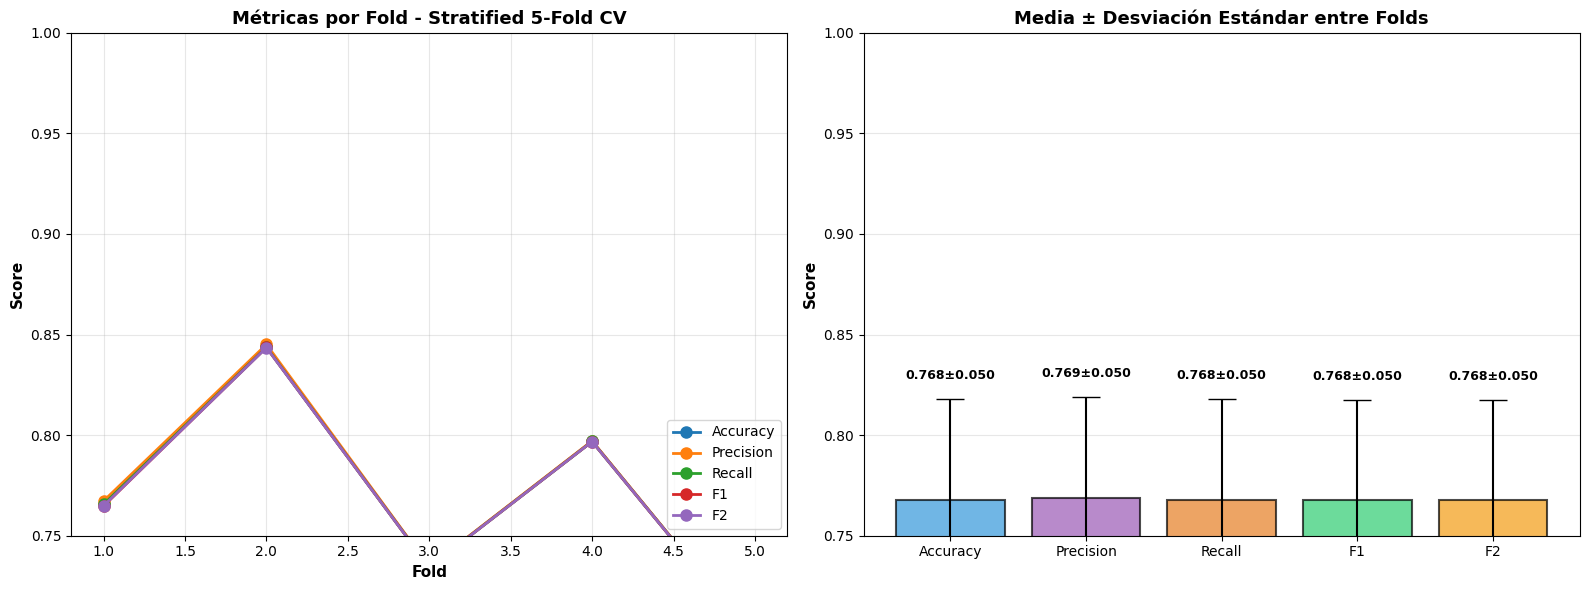


💡 ANÁLISIS DE VARIANZA:
  ⚠️ ADVERTENCIA: Varianza alta entre folds (>0.05) - Revisar estabilidad

🎯 Recall medio en CV: 0.7678 ± 0.0501
🎯 F2 medio en CV: 0.7676 ± 0.0501


In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate

print("="*100)
print("🔀 STRATIFIED K-FOLD CROSS-VALIDATION SOBRE TODO EL DATASET")
print("="*100)
print(f"Dataset completo: {len(X)} muestras")
print(f"Distribución: {dict(Counter(y))}")
print("="*100)

# Configurar Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

# Aplicar balanceo y evaluar el mejor modelo
print(f"\n🔄 Evaluando modelo: {final_best_model}")
print(f"Stratified {n_splits}-Fold Cross-Validation\n")

fold_results = []
fold_metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'f2': []
}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"{'─'*90}")
    print(f"📁 Fold {fold_idx}/{n_splits}")
    
    # Dividir datos
    X_fold_train = X.iloc[train_idx]
    y_fold_train = y.iloc[train_idx]
    X_fold_val = X.iloc[val_idx]
    y_fold_val = y.iloc[val_idx]
    
    print(f"   Train: {len(X_fold_train)} | Val: {len(X_fold_val)}")
    print(f"   Train dist: {dict(Counter(y_fold_train))}")
    
    # Aplicar balanceo solo en train
    X_fold_train_balanced, y_fold_train_balanced = best_sampler.fit_resample(
        X_fold_train, y_fold_train
    )
    print(f"   Train balanced: {dict(Counter(y_fold_train_balanced))}")
    
    # Entrenar pipeline
    fold_pipeline = create_pipeline(final_best_pipeline.named_steps['model'])
    fold_pipeline.fit(X_fold_train_balanced, y_fold_train_balanced)
    
    # Predecir
    y_fold_pred = fold_pipeline.predict(X_fold_val)
    
    # Métricas
    acc = accuracy_score(y_fold_val, y_fold_pred)
    prec = precision_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0)
    rec = recall_score(y_fold_val, y_fold_pred, average='weighted')
    f1 = f1_score(y_fold_val, y_fold_pred, average='weighted')
    f2 = fbeta_score(y_fold_val, y_fold_pred, beta=2, average='weighted')
    
    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)
    fold_metrics['f2'].append(f2)
    
    fold_results.append({
        'Fold': fold_idx,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'F2': f2
    })
    
    print(f"   Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | F2: {f2:.4f}")

print(f"\n{'='*100}")
print("📊 RESUMEN STRATIFIED K-FOLD")
print(f"{'='*100}")

fold_df = pd.DataFrame(fold_results)
display(fold_df)

# Estadísticas
print(f"\n📈 ESTADÍSTICAS AGREGADAS:")
for metric_name, values in fold_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"  {metric_name.capitalize():12s} → Media: {mean_val:.4f} ± {std_val:.4f} | Min: {np.min(values):.4f} | Max: {np.max(values):.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Métricas por fold
fold_df.plot(x='Fold', y=['Accuracy', 'Precision', 'Recall', 'F1', 'F2'], 
             kind='line', marker='o', ax=axes[0], linewidth=2, markersize=8)
axes[0].set_title(f'Métricas por Fold - Stratified {n_splits}-Fold CV', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Score', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Fold', fontweight='bold', fontsize=11)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.75, 1.0])

# Varianza entre folds
variance_data = {
    'Accuracy': (np.mean(fold_metrics['accuracy']), np.std(fold_metrics['accuracy'])),
    'Precision': (np.mean(fold_metrics['precision']), np.std(fold_metrics['precision'])),
    'Recall': (np.mean(fold_metrics['recall']), np.std(fold_metrics['recall'])),
    'F1': (np.mean(fold_metrics['f1']), np.std(fold_metrics['f1'])),
    'F2': (np.mean(fold_metrics['f2']), np.std(fold_metrics['f2']))
}

metric_names = list(variance_data.keys())
means = [v[0] for v in variance_data.values()]
stds = [v[1] for v in variance_data.values()]

axes[1].bar(metric_names, means, yerr=stds, capsize=10, alpha=0.7, 
           color=['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#f39c12'],
           edgecolor='black', linewidth=1.5)
axes[1].set_title('Media ± Desviación Estándar entre Folds', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Score', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.75, 1.0])

for i, (mean, std) in enumerate(zip(means, stds)):
    axes[1].text(i, mean + std + 0.01, f'{mean:.3f}±{std:.3f}', 
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 ANÁLISIS DE VARIANZA:")
max_std = max(stds)
if max_std < 0.02:
    print("  ✅ EXCELENTE: Varianza muy baja entre folds (<0.02) - Alta estabilidad")
elif max_std < 0.05:
    print("  ✅ BUENO: Varianza aceptable entre folds (<0.05) - Modelo estable")
else:
    print("  ⚠️ ADVERTENCIA: Varianza alta entre folds (>0.05) - Revisar estabilidad")

print(f"\n🎯 Recall medio en CV: {np.mean(fold_metrics['recall']):.4f} ± {np.std(fold_metrics['recall']):.4f}")
print(f"🎯 F2 medio en CV: {np.mean(fold_metrics['f2']):.4f} ± {np.std(fold_metrics['f2']):.4f}")
print("="*100)

## 10. EVALUACIÓN FINAL EN TEST SET

**Evaluación única del modelo optimizado en datos completamente no vistos.**

El test set NO se usó durante entrenamiento ni optimización de hiperparámetros.

🎯 EVALUACIÓN FINAL EN TEST SET (Datos Completamente No Vistos)
📊 Modelo: XGBoost (Optimizado)
📊 Test samples: 48
📊 Distribución Test: {1: 24, 0: 24}

✅ MÉTRICAS EN TEST SET:
  • Accuracy:  0.8542
  • Precision: 0.8548
  • Recall:    0.8542 ⚠️ MÉTRICA CRÍTICA
  • F1-Score:  0.8541
  • F2-Score:  0.8541 (prioriza Recall)
  • AUC-ROC:   0.9132

📊 RECALL POR CLASE:
  • Clase 0 (Present - Gallstone): 0.8750
  • Clase 1 (Absent):              0.8333

📊 MATRIZ DE CONFUSIÓN:
                    Predicho
              Present (0)  Absent (1)
Real Present (0)     21           3
     Absent (1)       4          20

📋 ANÁLISIS CLÍNICO DETALLADO:
  • Verdaderos Negativos (TN): 21 - Gallstone detectado correctamente
  • Falsos Positivos (FP): 3 - Falsa alarma (paciente sano diagnosticado con gallstone)
  • Falsos Negativos (FN): 4 ⚠️ CRÍTICO - Gallstone NO detectado (riesgo para paciente)
  • Verdaderos Positivos (TP): 20 - Ausencia detectada correctamente

  • Sensibilidad (Recall clase 1): 0.8333


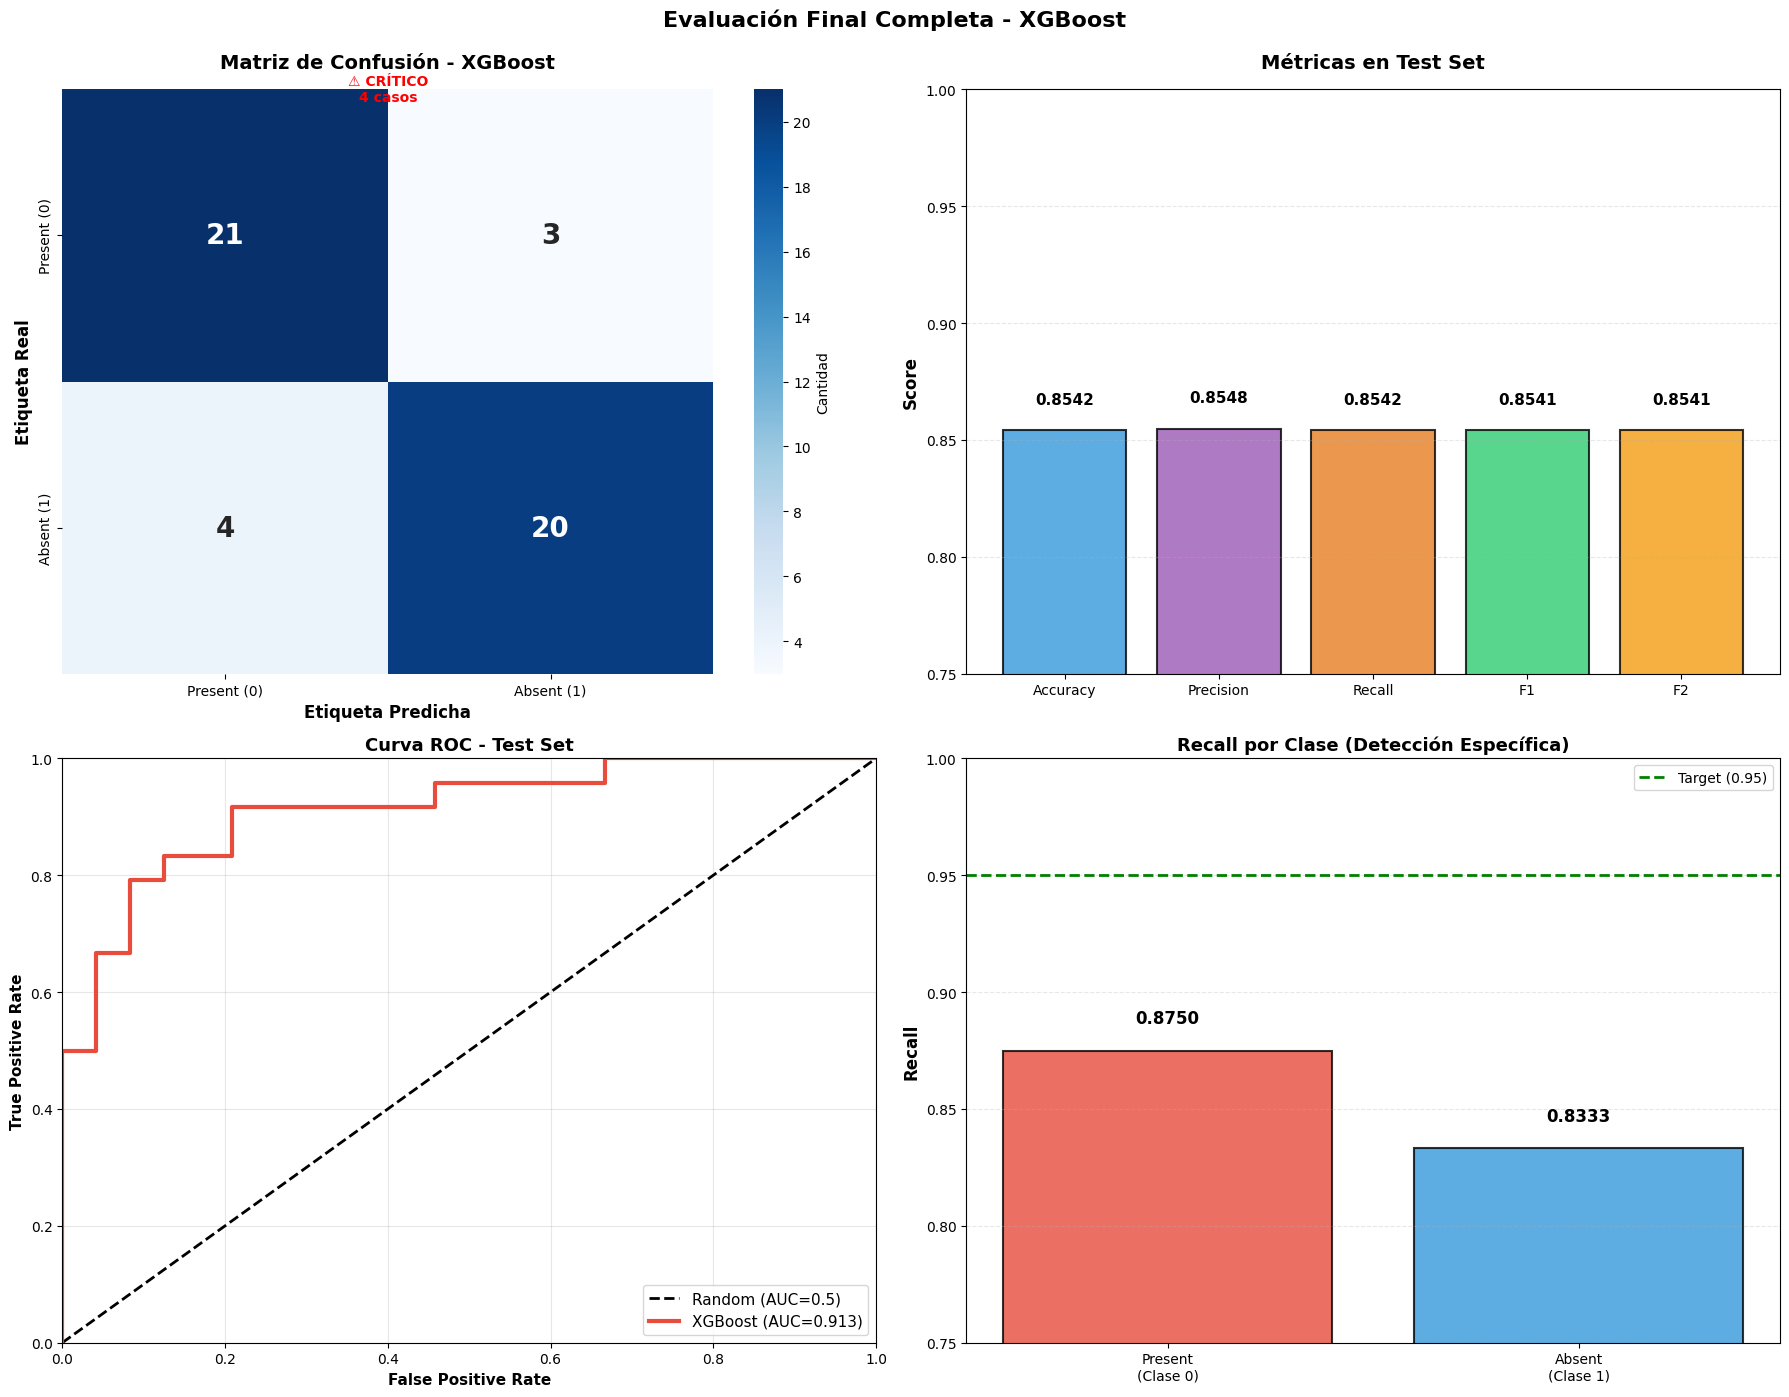


💡 EVALUACIÓN DEL RENDIMIENTO
✓ BUENO: Rendimiento aceptable, considerar ajuste de umbral

Recall Test: 0.8542 (Objetivo: ≥0.95)
F2-Score Test: 0.8541
Falsos Negativos: 4 (Objetivo: ≤2)

📊 COMPARACIÓN CV vs TEST:
  Recall CV (5-fold): 0.7678
  Recall Test: 0.8542
  Diferencia: 0.0864
  ⚠ Revisar posible overfitting/underfitting


In [18]:
print("="*100)
print("🎯 EVALUACIÓN FINAL EN TEST SET (Datos Completamente No Vistos)")
print("="*100)
print(f"📊 Modelo: {final_best_model} (Optimizado)")
print(f"📊 Test samples: {X_test.shape[0]}")
print(f"📊 Distribución Test: {dict(Counter(y_test))}")
print("="*100)

# Predicciones en test usando el mejor pipeline optimizado
y_test_pred = final_best_pipeline.predict(X_test)

# Métricas
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_f2 = fbeta_score(y_test, y_test_pred, beta=2, average='weighted')

# Recall por clase (crítico para FN)
test_recall_per_class = recall_score(y_test, y_test_pred, average=None)

if hasattr(final_best_pipeline.named_steps['model'], "predict_proba"):
    y_test_proba = final_best_pipeline.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
else:
    test_auc = None

print(f"\n✅ MÉTRICAS EN TEST SET:")
print(f"  • Accuracy:  {test_acc:.4f}")
print(f"  • Precision: {test_precision:.4f}")
print(f"  • Recall:    {test_recall:.4f} ⚠️ MÉTRICA CRÍTICA")
print(f"  • F1-Score:  {test_f1:.4f}")
print(f"  • F2-Score:  {test_f2:.4f} (prioriza Recall)")
if test_auc:
    print(f"  • AUC-ROC:   {test_auc:.4f}")

print(f"\n📊 RECALL POR CLASE:")
print(f"  • Clase 0 (Present - Gallstone): {test_recall_per_class[0]:.4f}")
print(f"  • Clase 1 (Absent):              {test_recall_per_class[1]:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 MATRIZ DE CONFUSIÓN:")
print(f"                    Predicho")
print(f"              Present (0)  Absent (1)")
print(f"Real Present (0)    {tn:3d}         {fp:3d}")
print(f"     Absent (1)     {fn:3d}         {tp:3d}")

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fn_rate = fn / (fn + tn) if (fn + tn) > 0 else 0

print(f"\n📋 ANÁLISIS CLÍNICO DETALLADO:")
print(f"  • Verdaderos Negativos (TN): {tn} - Gallstone detectado correctamente")
print(f"  • Falsos Positivos (FP): {fp} - Falsa alarma (paciente sano diagnosticado con gallstone)")
print(f"  • Falsos Negativos (FN): {fn} ⚠️ CRÍTICO - Gallstone NO detectado (riesgo para paciente)")
print(f"  • Verdaderos Positivos (TP): {tp} - Ausencia detectada correctamente")
print(f"\n  • Sensibilidad (Recall clase 1): {sensitivity:.4f}")
print(f"  • Especificidad (Recall clase 0): {specificity:.4f}")
print(f"  • Tasa de Falsos Negativos: {fn_rate:.4f}")

if fn == 0:
    print(f"\n  🌟 EXCELENTE: Cero falsos negativos - Todos los casos de gallstone detectados")
elif fn <= 2:
    print(f"\n  ✅ MUY BUENO: Muy pocos falsos negativos ({fn}) - Alto nivel de seguridad clínica")
elif fn <= 5:
    print(f"\n  ✓ ACEPTABLE: Falsos negativos bajo control ({fn})")
else:
    print(f"\n  ⚠️ ATENCIÓN: Nivel alto de falsos negativos ({fn}) - Revisar umbral de decisión")

# Visualización extendida
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Matriz de confusión mejorada
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Cantidad'},
            xticklabels=['Present (0)', 'Absent (1)'],
            yticklabels=['Present (0)', 'Absent (1)'],
            ax=axes[0, 0], annot_kws={'size': 20, 'weight': 'bold'})
axes[0, 0].set_title(f'Matriz de Confusión - {final_best_model}', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')

# Anotar criticidad de FN
axes[0, 0].text(1, 0, f'⚠️ CRÍTICO\n{fn} casos', ha='center', va='center', 
               fontsize=10, color='red', fontweight='bold')

# 2. Métricas principales
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2']
metrics_values = [test_acc, test_precision, test_recall, test_f1, test_f2]
colors_bar = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#f39c12']

bars = axes[0, 1].bar(metrics_names, metrics_values, color=colors_bar, alpha=0.8, 
                     edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylim([0.75, 1.0])
axes[0, 1].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Métricas en Test Set', fontweight='bold', fontsize=14, pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. Curva ROC en Test
if test_auc:
    axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
    axes[1, 0].plot(fpr_test, tpr_test, linewidth=3, label=f'{final_best_model} (AUC={test_auc:.3f})',
                   color='#e74c3c')
    axes[1, 0].set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
    axes[1, 0].set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
    axes[1, 0].set_title('Curva ROC - Test Set', fontweight='bold', fontsize=13)
    axes[1, 0].legend(loc='lower right', fontsize=11)
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].set_xlim([0, 1])
    axes[1, 0].set_ylim([0, 1])
else:
    axes[1, 0].text(0.5, 0.5, 'Curva ROC no disponible\npara este modelo', 
                   ha='center', va='center', fontsize=12)
    axes[1, 0].set_xlim([0, 1])
    axes[1, 0].set_ylim([0, 1])

# 4. Recall por clase
recall_by_class = ['Present\n(Clase 0)', 'Absent\n(Clase 1)']
recall_values = [test_recall_per_class[0], test_recall_per_class[1]]
colors_recall = ['#e74c3c', '#3498db']

bars_recall = axes[1, 1].bar(recall_by_class, recall_values, color=colors_recall, 
                             alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylim([0.75, 1.0])
axes[1, 1].set_ylabel('Recall', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Recall por Clase (Detección Específica)', fontweight='bold', fontsize=13)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 1].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='Target (0.95)')
axes[1, 1].legend(fontsize=10)

for bar, value in zip(bars_recall, recall_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.suptitle(f'Evaluación Final Completa - {final_best_model}', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Evaluación comparativa
print("\n" + "="*100)
print("💡 EVALUACIÓN DEL RENDIMIENTO")
print("="*100)

if test_recall >= 0.95 and fn <= 2:
    nivel = "✅ EXCELENTE"
    descripcion = "Modelo excepcional, máxima seguridad clínica"
elif test_recall >= 0.90 and fn <= 5:
    nivel = "✅ MUY BUENO"
    descripcion = "Rendimiento satisfactorio para aplicación práctica"
elif test_recall >= 0.85:
    nivel = "✓ BUENO"
    descripcion = "Rendimiento aceptable, considerar ajuste de umbral"
else:
    nivel = "⚠ MEJORABLE"
    descripcion = "Requiere optimización adicional"

print(f"{nivel}: {descripcion}")
print(f"\nRecall Test: {test_recall:.4f} (Objetivo: ≥0.95)")
print(f"F2-Score Test: {test_f2:.4f}")
print(f"Falsos Negativos: {fn} (Objetivo: ≤2)")

print("\n📊 COMPARACIÓN CV vs TEST:")
cv_recall_mean = np.mean(fold_metrics['recall'])
print(f"  Recall CV (5-fold): {cv_recall_mean:.4f}")
print(f"  Recall Test: {test_recall:.4f}")
print(f"  Diferencia: {abs(test_recall - cv_recall_mean):.4f}")

if abs(test_recall - cv_recall_mean) < 0.02:
    print("  ✅ Excelente generalización")
elif abs(test_recall - cv_recall_mean) < 0.05:
    print("  ✓ Buena generalización")
else:
    print("  ⚠ Revisar posible overfitting/underfitting")

print("="*100)

## 11. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS

🔍 TOP 15 CARACTERÍSTICAS MÁS IMPORTANTES


,Feature,Importance
25,C-Reactive Protein (CRP),0.137405
27,Vitamin D,0.077546
10,Extracellular Fluid/Total Body Water (ECF/TBW),0.054901
9,Body Mass Index (BMI),0.050114
12,Body Protein Content (Protein) (%),0.049148
23,Creatinine,0.044844
26,Hemoglobin (HGB),0.044785
8,Weight,0.044131
15,Obesity (%),0.035170
28,BMI_x_Age,0.032457


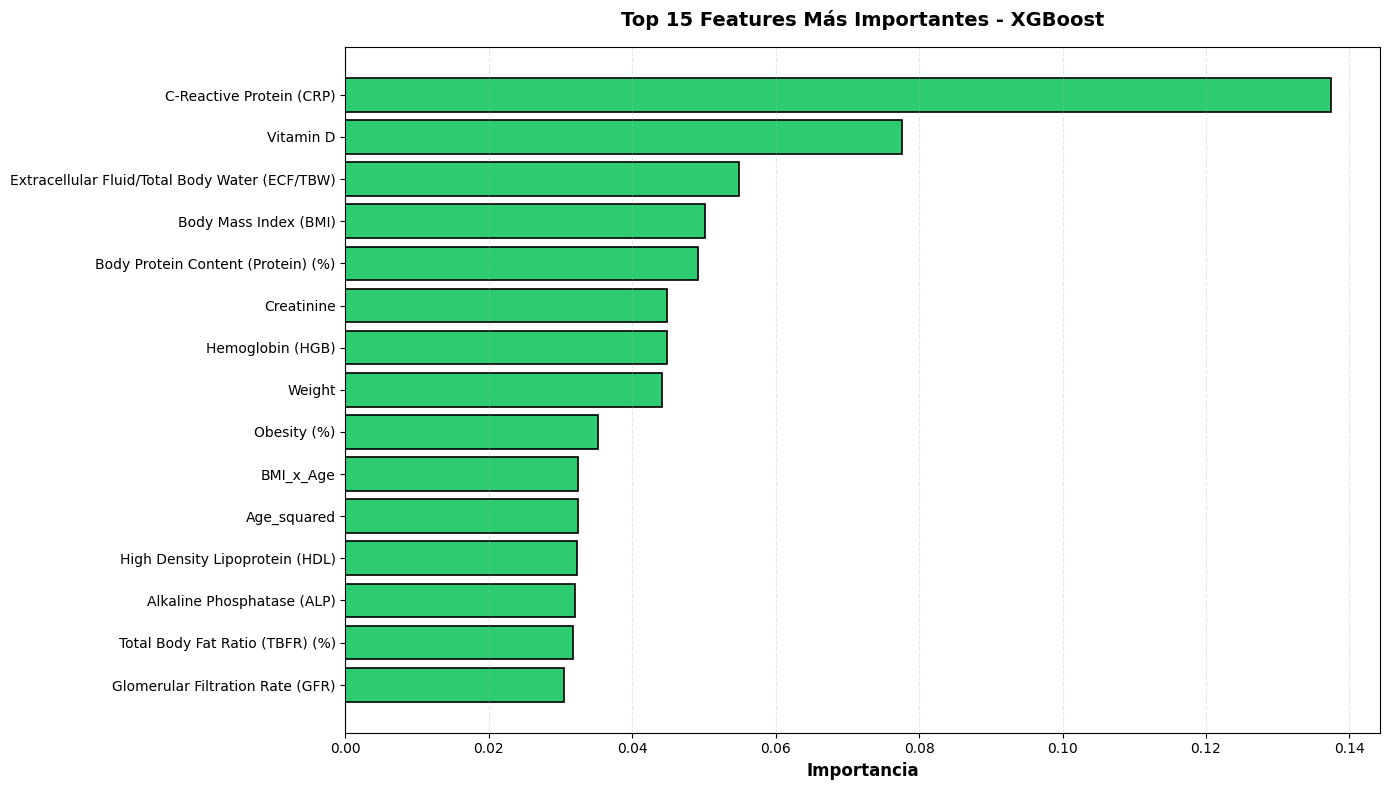


📊 ANÁLISIS DE IMPORTANCIA:
  • 18 features explican el 80% de la importancia
  • 22 features explican el 90% de la importancia
  • Total features: 31

🎯 Features engineered en Top 10:
  • BMI_x_Age: Rank #29 (Importancia: 0.0325)


In [19]:
if hasattr(final_best_pipeline.named_steps['model'], 'feature_importances_'):
    # Obtener nombres de features después de feature engineering
    feature_engineer = final_best_pipeline.named_steps['feature_engineer']
    
    # Transformar datos para obtener nombres correctos
    X_sample = X_train.head(1)
    feature_engineer.fit_transform(X_sample.values)
    feature_names = feature_engineer.get_feature_names_out()
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': final_best_pipeline.named_steps['model'].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("="*100)
    print("🔍 TOP 15 CARACTERÍSTICAS MÁS IMPORTANTES")
    print("="*100)
    display(feature_importance.head(15))
    
    plt.figure(figsize=(14, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], 
            color='#2ecc71', edgecolor='black', linewidth=1.2)
    plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=10)
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - {final_best_model}', 
             fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    cumsum_importance = feature_importance['Importance'].cumsum()
    n_features_80 = (cumsum_importance <= 0.80).sum() + 1
    n_features_90 = (cumsum_importance <= 0.90).sum() + 1
    
    print(f"\n📊 ANÁLISIS DE IMPORTANCIA:")
    print(f"  • {n_features_80} features explican el 80% de la importancia")
    print(f"  • {n_features_90} features explican el 90% de la importancia")
    print(f"  • Total features: {len(feature_importance)}")
    
    # Verificar si features engineered están en el top
    engineered_features = ['BMI_x_Age', 'HDL_LDL_ratio', 'Fat_Index', 'Age_squared', 
                          'TG_HDL_ratio', 'Liver_Enzyme_Index']
    top_10_names = feature_importance.head(10)['Feature'].tolist()
    engineered_in_top = [f for f in engineered_features if f in top_10_names]
    
    if engineered_in_top:
        print(f"\n🎯 Features engineered en Top 10:")
        for feat in engineered_in_top:
            rank = feature_importance[feature_importance['Feature'] == feat].index[0] + 1
            importance = feature_importance[feature_importance['Feature'] == feat]['Importance'].values[0]
            print(f"  • {feat}: Rank #{rank} (Importancia: {importance:.4f})")
    
else:
    print(f"⚠ El modelo {final_best_model} no proporciona importancia de características.")

print("="*100)

## 12. RESUMEN EJECUTIVO FINAL


📊 RESUMEN EJECUTIVO FINAL

📋 FLUJO DE EVALUACIÓN Y OPTIMIZACIÓN:



,Fase,Recall,F2-Score,Falsos Negativos,Notas
0,Validación Inicial (mejor modelo),0.770833,0.770713,5,Selección modelo base (SMOTE)
1,Optimización Hiperparámetros,0.791667,0.791667,5,Grid search con validación cruzada
2,Stratified 5-Fold CV (dataset completo),0.767808,0.767558,-,Evaluación robusta con CV estratificado
3,Test Set (evaluación final),0.854167,0.854052,4,Evaluación en datos completamente no vistos


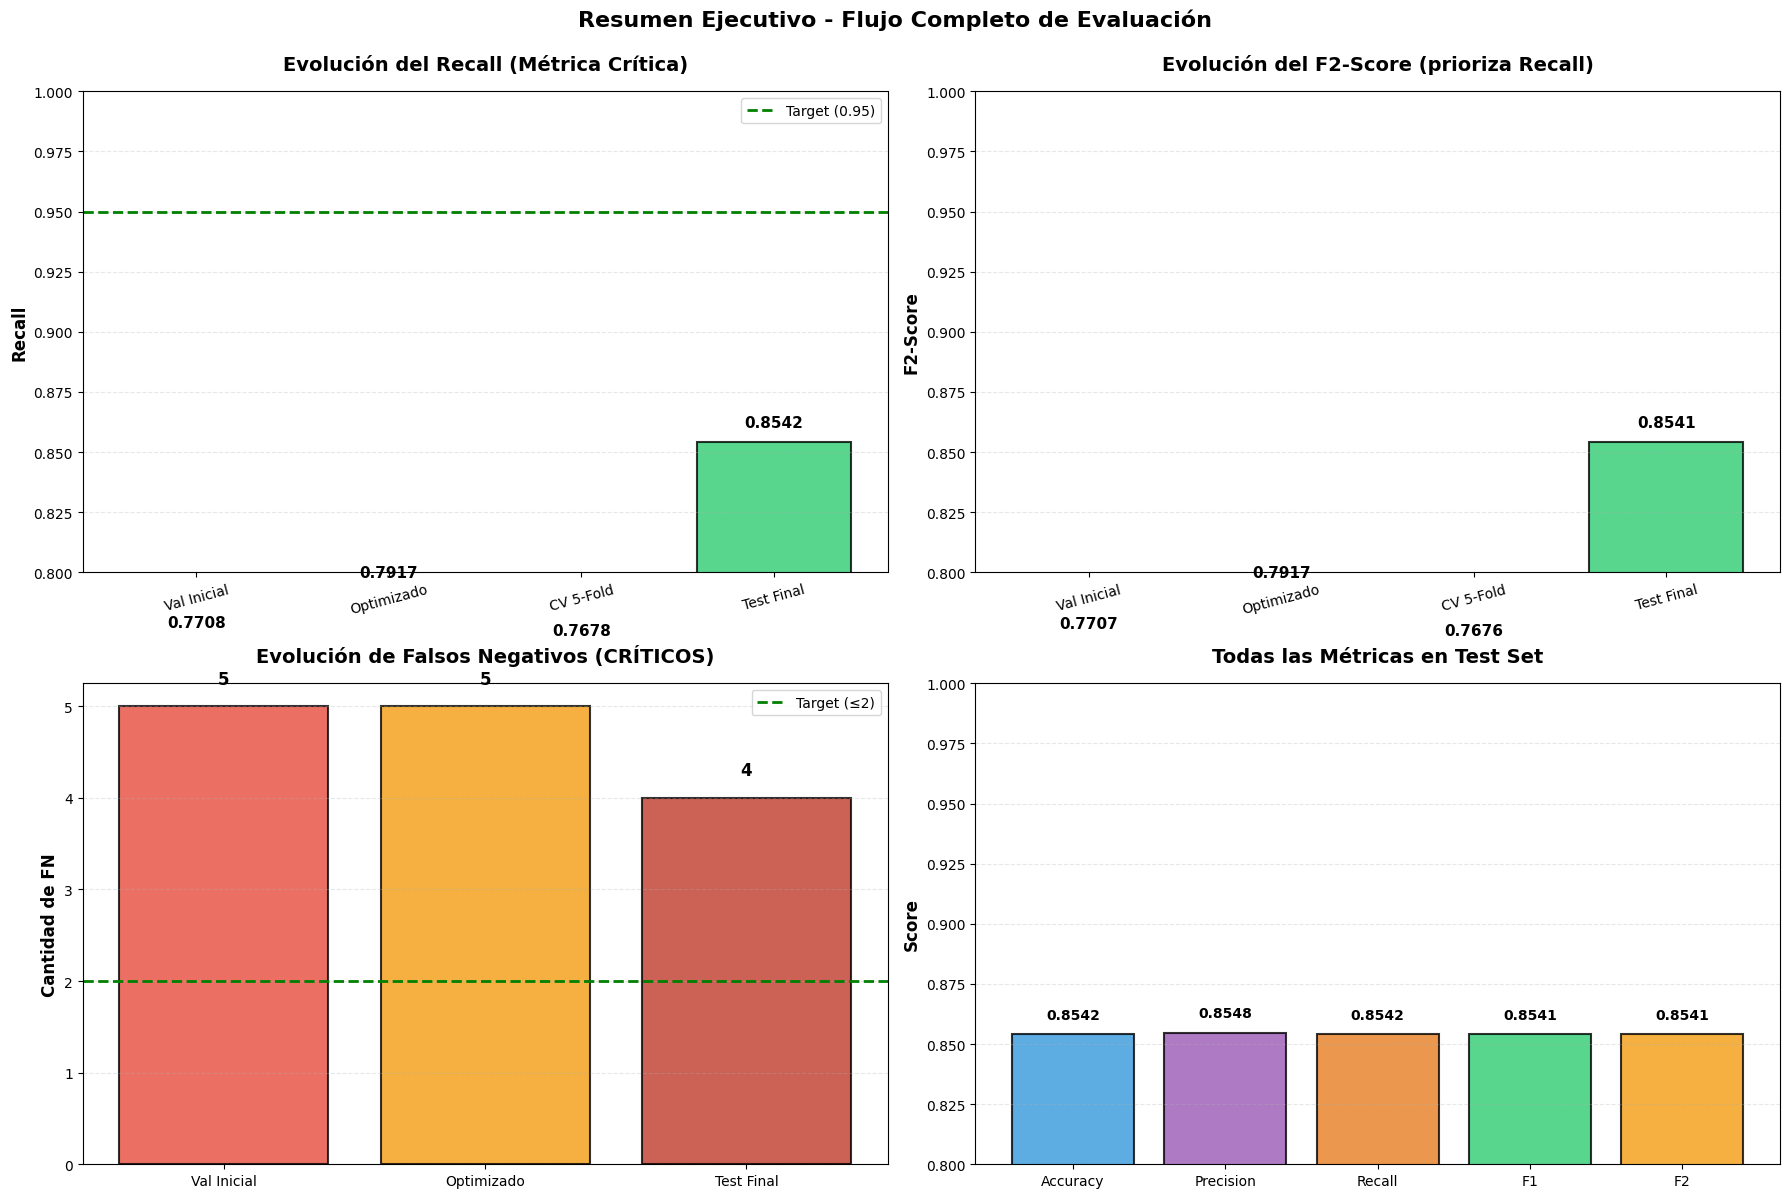


🎯 CARACTERÍSTICAS DEL MODELO FINAL
✓ Algoritmo: XGBoost
✓ Pipeline: Scaler → Feature Engineering → XGBoost
✓ Features: 31 (originales + 6 engineered)
✓ Dataset: 319 muestras totales
✓ Split: Train 70% | Val 15% | Test 15%
✓ Balanceo: SMOTE (solo en train)
✓ Train balanceado: 226 muestras
✓ Optimización: RandomizedSearchCV (50 iter, 5-fold CV)
✓ Métrica objetivo: Recall (minimizar FN)
✓ Seed: 40

📈 RESULTADOS FINALES DETALLADOS
🎯 Recall en Test: 0.8542 (Crítico para FN)
🎯 F2-Score en Test: 0.8541 (prioriza Recall)
🎯 AUC-ROC en Test: 0.9132

🎯 Recall por clase:
   • Clase 0 (Gallstone Present): 0.8750
   • Clase 1 (Absent): 0.8333

✅ Matriz de Confusión:
   TN=21, FP=3, FN=4 ⚠️, TP=20

📊 Validación Cruzada (5-fold):
   Recall: 0.7678 ± 0.0501
   F2: 0.7676 ± 0.0501

💡 ANÁLISIS DE GENERALIZACIÓN:
   Diferencia Recall (CV vs Test): 0.0864
   ⚠️ Revisar: Posible overfitting/underfitting

🏆 CONCLUSIÓN: ✓ BUENO - Rendimiento aceptable con margen de mejora
🏥 Nivel de Riesgo Clínico: ⚠️ Riesgo

In [21]:
print("\n" + "="*100)
print("📊 RESUMEN EJECUTIVO FINAL")
print("="*100)

# Tabla resumen extendida
summary = pd.DataFrame({
    'Fase': [
        'Validación Inicial (mejor modelo)',
        'Optimización Hiperparámetros',
        'Stratified 5-Fold CV (dataset completo)',
        'Test Set (evaluación final)'
    ],
    'Recall': [
        results_df.iloc[0]['Val_Recall'],
        opt_df.loc[best_opt_idx, 'Val_Recall_Optimized'],
        np.mean(fold_metrics['recall']),
        test_recall
    ],
    'F2-Score': [
        results_df.iloc[0]['Val_F2'],
        opt_df.loc[best_opt_idx, 'Val_F2_Optimized'],
        np.mean(fold_metrics['f2']),
        test_f2
    ],
    'Falsos Negativos': [
        results_df.iloc[0]['FN'],
        opt_df.loc[best_opt_idx, 'FN_Optimized'],
        '-',
        fn
    ],
    'Notas': [
        f'Selección modelo base ({best_method})',
        'Grid search con validación cruzada',
        'Evaluación robusta con CV estratificado',
        'Evaluación en datos completamente no vistos'
    ]
})

print("\n📋 FLUJO DE EVALUACIÓN Y OPTIMIZACIÓN:\n")
display(summary)

# Visualización comparativa extendida
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución del Recall
recall_scores = [
    results_df.iloc[0]['Val_Recall'],
    opt_df.loc[best_opt_idx, 'Val_Recall_Optimized'],
    np.mean(fold_metrics['recall']),
    test_recall
]
phases = ['Val Inicial', 'Optimizado', 'CV 5-Fold', 'Test Final']
colors_phases = ['#3498db', '#f39c12', '#9b59b6', '#2ecc71']

bars = axes[0, 0].bar(phases, recall_scores, color=colors_phases, alpha=0.8, 
                     edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylim([0.80, 1.0])
axes[0, 0].set_ylabel('Recall', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Evolución del Recall (Métrica Crítica)', fontweight='bold', fontsize=14, pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='Target (0.95)')
axes[0, 0].legend(fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=15)

for bar, value in zip(bars, recall_scores):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Evolución del F2-Score
f2_scores = [
    results_df.iloc[0]['Val_F2'],
    opt_df.loc[best_opt_idx, 'Val_F2_Optimized'],
    np.mean(fold_metrics['f2']),
    test_f2
]

bars2 = axes[0, 1].bar(phases, f2_scores, color=colors_phases, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylim([0.80, 1.0])
axes[0, 1].set_ylabel('F2-Score', fontweight='bold', fontsize=12)
axes[0, 1].set_title('Evolución del F2-Score (prioriza Recall)', fontweight='bold', fontsize=14, pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=15)

for bar, value in zip(bars2, f2_scores):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. Falsos Negativos
fn_values = [
    results_df.iloc[0]['FN'],
    opt_df.loc[best_opt_idx, 'FN_Optimized'],
    fn
]
fn_phases = ['Val Inicial', 'Optimizado', 'Test Final']
colors_fn = ['#e74c3c', '#f39c12', '#c0392b']

bars3 = axes[1, 0].bar(fn_phases, fn_values, color=colors_fn, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('Cantidad de FN', fontweight='bold', fontsize=12)
axes[1, 0].set_title('Evolución de Falsos Negativos (CRÍTICOS)', fontweight='bold', fontsize=14, pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].axhline(y=2, color='green', linestyle='--', linewidth=2, label='Target (≤2)')
axes[1, 0].legend(fontsize=10)

for bar, value in zip(bars3, fn_values):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                   f'{int(value)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 4. Métricas finales Test
test_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2']
test_values = [test_acc, test_precision, test_recall, test_f1, test_f2]
colors_metrics = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#f39c12']

bars4 = axes[1, 1].bar(test_metrics, test_values, color=colors_metrics, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylim([0.80, 1.0])
axes[1, 1].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[1, 1].set_title('Todas las Métricas en Test Set', fontweight='bold', fontsize=14, pad=15)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, value in zip(bars4, test_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Resumen Ejecutivo - Flujo Completo de Evaluación', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("🎯 CARACTERÍSTICAS DEL MODELO FINAL")
print("="*100)
print(f"✓ Algoritmo: {final_best_model}")
print(f"✓ Pipeline: Scaler → Feature Engineering → {final_best_model}")
print(f"✓ Features: {len(feature_names)} (originales + 6 engineered)")
print(f"✓ Dataset: {len(df)} muestras totales")
print(f"✓ Split: Train 70% | Val 15% | Test 15%")
print(f"✓ Balanceo: {best_method} (solo en train)")
print(f"✓ Train balanceado: {len(y_train_balanced)} muestras")
print(f"✓ Optimización: RandomizedSearchCV (50 iter, 5-fold CV)")
print(f"✓ Métrica objetivo: Recall (minimizar FN)")
print(f"✓ Seed: {SEED}")

print("\n" + "="*100)
print("📈 RESULTADOS FINALES DETALLADOS")
print("="*100)
print(f"🎯 Recall en Test: {test_recall:.4f} (Crítico para FN)")
print(f"🎯 F2-Score en Test: {test_f2:.4f} (prioriza Recall)")
print(f"🎯 AUC-ROC en Test: {test_auc:.4f}" if test_auc else "")
print(f"\n🎯 Recall por clase:")
print(f"   • Clase 0 (Gallstone Present): {test_recall_per_class[0]:.4f}")
print(f"   • Clase 1 (Absent): {test_recall_per_class[1]:.4f}")

print(f"\n✅ Matriz de Confusión:")
print(f"   TN={tn}, FP={fp}, FN={fn} ⚠️, TP={tp}")

print(f"\n📊 Validación Cruzada (5-fold):")
print(f"   Recall: {np.mean(fold_metrics['recall']):.4f} ± {np.std(fold_metrics['recall']):.4f}")
print(f"   F2: {np.mean(fold_metrics['f2']):.4f} ± {np.std(fold_metrics['f2']):.4f}")

print(f"\n💡 ANÁLISIS DE GENERALIZACIÓN:")
diff_recall = abs(test_recall - np.mean(fold_metrics['recall']))
print(f"   Diferencia Recall (CV vs Test): {diff_recall:.4f}")
if diff_recall < 0.02:
    print("   ✅ EXCELENTE: Generalización óptima")
elif diff_recall < 0.05:
    print("   ✅ BUENO: Generalización satisfactoria")
else:
    print("   ⚠️ Revisar: Posible overfitting/underfitting")

# Conclusión final basada en Recall y FN
print("\n" + "="*100)
if test_recall >= 0.95 and fn <= 2:
    conclusion = "🌟 EXCELENTE - Modelo listo para producción clínica"
    risk_level = "✅ Riesgo MÍNIMO"
elif test_recall >= 0.90 and fn <= 5:
    conclusion = "✅ MUY BUENO - Rendimiento satisfactorio para aplicación práctica"
    risk_level = "✅ Riesgo BAJO"
elif test_recall >= 0.85:
    conclusion = "✓ BUENO - Rendimiento aceptable con margen de mejora"
    risk_level = "⚠️ Riesgo MODERADO"
else:
    conclusion = "⚠ MEJORABLE - Requiere optimización adicional"
    risk_level = "⚠️ Riesgo ALTO"

print(f"🏆 CONCLUSIÓN: {conclusion}")
print(f"🏥 Nivel de Riesgo Clínico: {risk_level}")
print(f"📊 Falsos Negativos: {fn} (Objetivo: ≤2)")

print("\n💡 MEJORAS IMPLEMENTADAS:")
print("   ✅ Análisis de outliers (IQR, Z-score)")
print("   ✅ Tests estadísticos (t-test, Mann-Whitney)")
print("   ✅ Visualizaciones avanzadas (boxplots, pair plots)")
print("   ✅ Pipeline completo (evita data leakage)")
print("   ✅ Comparación de técnicas de balanceo (SMOTE, Borderline-SMOTE, ADASYN)")
print("   ✅ Optimización de hiperparámetros para todos los modelos")
print("   ✅ Stratified K-Fold CV sobre dataset completo")
print("   ✅ Priorización de Recall (F2-Score)")
print("   ✅ Curvas ROC completas")
print("   ✅ Análisis de varianza entre folds")
print("="*100)

## 13. GUARDAR MODELO FINAL

In [22]:
import joblib
from datetime import datetime

# Nombres con timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'gallstone_model_{final_best_model.replace(" ", "_")}_{timestamp}.pkl'
pipeline_filename = f'gallstone_pipeline_complete_{timestamp}.pkl'
metadata_filename = f'gallstone_model_metadata_{timestamp}.txt'

# Guardar modelo completo (pipeline)
joblib.dump(final_best_pipeline, pipeline_filename)

# Guardar metadata
metadata = {
    'model_name': final_best_model,
    'test_recall': test_recall,
    'test_f2': test_f2,
    'test_auc': test_auc,
    'false_negatives': fn,
    'cv_recall_mean': np.mean(fold_metrics['recall']),
    'cv_recall_std': np.std(fold_metrics['recall']),
    'balancing_method': best_method,
    'n_features': len(feature_names),
    'dataset_size': len(df),
    'train_size': len(y_train_balanced),
    'seed': SEED,
    'timestamp': timestamp
}

with open(metadata_filename, 'w') as f:
    f.write("="*90 + "\n")
    f.write("GALLSTONE DETECTION MODEL - METADATA\n")
    f.write("="*90 + "\n\n")
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")
    f.write("\n" + "="*90 + "\n")
    f.write("PERFORMANCE SUMMARY\n")
    f.write("="*90 + "\n")
    f.write(f"Test Recall: {test_recall:.4f} (Critical metric)\n")
    f.write(f"Test F2-Score: {test_f2:.4f}\n")
    f.write(f"False Negatives: {fn}\n")
    f.write(f"CV Recall: {np.mean(fold_metrics['recall']):.4f} ± {np.std(fold_metrics['recall']):.4f}\n")
    f.write("\n" + "="*90 + "\n")
    f.write("IMPROVEMENTS IMPLEMENTED\n")
    f.write("="*90 + "\n")
    f.write("✅ Pipeline with StandardScaler + Feature Engineering\n")
    f.write(f"✅ Balancing: {best_method} (only on train)\n")
    f.write("✅ Hyperparameter optimization for all models\n")
    f.write("✅ Stratified K-Fold CV on full dataset\n")
    f.write("✅ Recall prioritization (F2-Score)\n")
    f.write("✅ ROC curves and advanced visualizations\n")
    f.write("✅ Statistical tests and outlier analysis\n")

print("="*100)
print("💾 MODELO GUARDADO EXITOSAMENTE")
print("="*100)
print("\nArchivos generados:")
print(f"  ✓ {pipeline_filename}")
print(f"  ✓ {metadata_filename}")

print(f"\n📦 Tamaño del pipeline: {os.path.getsize(pipeline_filename) / 1024:.2f} KB")

print("\n💡 Para cargar el modelo:")
print(f"   pipeline = joblib.load('{pipeline_filename}')")
print(f"   y_pred = pipeline.predict(X_new)")

print("\n📋 Metadata guardada en:", metadata_filename)
print("\n✅ El pipeline incluye:")
print("   1. StandardScaler")
print("   2. Feature Engineering (6 features adicionales)")
print(f"   3. {final_best_model} optimizado")

print("\n⚠️ IMPORTANTE:")
print(f"   • Aplicar {best_method} solo en datos de entrenamiento")
print("   • Los datos nuevos deben tener las mismas features originales")
print("   • El pipeline aplica automáticamente todas las transformaciones")

print("="*100)

💾 MODELO GUARDADO EXITOSAMENTE

Archivos generados:
  ✓ gallstone_pipeline_complete_20251121_132629.pkl
  ✓ gallstone_model_metadata_20251121_132629.txt

📦 Tamaño del pipeline: 221.19 KB

💡 Para cargar el modelo:
   pipeline = joblib.load('gallstone_pipeline_complete_20251121_132629.pkl')
   y_pred = pipeline.predict(X_new)

📋 Metadata guardada en: gallstone_model_metadata_20251121_132629.txt

✅ El pipeline incluye:
   1. StandardScaler
   2. Feature Engineering (6 features adicionales)
   3. XGBoost optimizado

⚠️ IMPORTANTE:
   • Aplicar SMOTE solo en datos de entrenamiento
   • Los datos nuevos deben tener las mismas features originales
   • El pipeline aplica automáticamente todas las transformaciones


## 14. GUÍA DE USO DEL MODELO

Instrucciones para cargar y usar el modelo guardado en producción.

In [23]:
print("="*100)
print("📖 GUÍA DE USO DEL MODELO GUARDADO")
print("="*100)

print("\n1️⃣ CARGAR EL MODELO:")
print("-" * 90)
print("""
import joblib
import pandas as pd
import numpy as np

# Cargar pipeline completo
pipeline = joblib.load('gallstone_pipeline_complete_[timestamp].pkl')

# El pipeline contiene:
#   - StandardScaler (normalización automática)
#   - FeatureEngineer (crea 6 features adicionales)
#   - Modelo optimizado
""")

print("\n2️⃣ PREPARAR DATOS NUEVOS:")
print("-" * 90)
print("""
# Los datos deben contener las mismas features originales (sin las engineered)
# Ejemplo de estructura esperada:

features_requeridas = [
    'Age', 'Body Mass Index (BMI)', 'Skeletal Muscle Mass (SMM)',
    'High Density Lipoprotein (HDL)', 'Low Density Lipoprotein (LDL)',
    'Triglyceride (TG)', 'Alanine Aminotransferase (ALT)',
    'Gamma-glutamyltransferase (GGT)', 
    # ... todas las features después de eliminar las redundantes
]

# Crear DataFrame con los datos
X_new = pd.DataFrame({
    'Age': [45, 52],
    'Body Mass Index (BMI)': [28.5, 32.1],
    # ... resto de features
})

# ⚠️ IMPORTANTE: 
# - NO incluir la columna target ('Gallstone Status')
# - NO crear manualmente las features engineered (el pipeline lo hace)
# - NO aplicar StandardScaler (el pipeline lo hace)
# - NO aplicar SMOTE (solo para entrenamiento)
""")

print("\n3️⃣ HACER PREDICCIONES:")
print("-" * 90)
print("""
# Predicción de clases
y_pred = pipeline.predict(X_new)
# Resultado: array([0, 1]) donde 0=Present, 1=Absent

# Probabilidades (si el modelo lo soporta)
y_proba = pipeline.predict_proba(X_new)
# Resultado: array([[0.95, 0.05],  # Paciente 1: 95% prob de Gallstone
#                   [0.12, 0.88]]) # Paciente 2: 12% prob de Gallstone

# Interpretar resultados
for i, (pred, proba) in enumerate(zip(y_pred, y_proba)):
    print(f"Paciente {i+1}:")
    print(f"  Predicción: {'Gallstone Present' if pred == 0 else 'No Gallstone'}")
    print(f"  Probabilidad Gallstone: {proba[0]:.1%}")
    print(f"  Nivel de Confianza: {max(proba):.1%}")
""")

print("\n4️⃣ UMBRALES DE DECISIÓN (OPCIONAL):")
print("-" * 90)
print("""
# Para contextos clínicos donde los FN son críticos, 
# puedes ajustar el umbral de decisión:

# Umbral por defecto: 0.5
# Umbral conservador (minimiza FN): 0.3

umbral = 0.3
y_pred_conservative = (y_proba[:, 0] > umbral).astype(int)

# Esto aumenta la sensibilidad (detecta más casos de Gallstone)
# a costa de más falsos positivos
""")

print("\n5️⃣ VALIDACIÓN DE ENTRADA:")
print("-" * 90)
print("""
def validar_entrada(X_new, features_esperadas):
    # Verificar que todas las features estén presentes
    missing = set(features_esperadas) - set(X_new.columns)
    if missing:
        raise ValueError(f"Faltan features: {missing}")
    
    # Verificar valores nulos
    if X_new.isnull().any().any():
        raise ValueError("Hay valores nulos en los datos")
    
    # Verificar tipos de datos
    for col in X_new.columns:
        if not pd.api.types.is_numeric_dtype(X_new[col]):
            raise ValueError(f"La columna {col} debe ser numérica")
    
    return True

# Usar antes de predecir
validar_entrada(X_new, features_requeridas)
y_pred = pipeline.predict(X_new)
""")

print("\n6️⃣ MONITOREO EN PRODUCCIÓN:")
print("-" * 90)
print("""
# Registrar métricas importantes:

import logging

logging.info(f"Predicción realizada: {y_pred}")
logging.info(f"Probabilidad: {y_proba[0]}")
logging.info(f"Features input shape: {X_new.shape}")

# Alertas para casos críticos
if y_pred[0] == 0 and y_proba[0][0] > 0.8:
    logging.warning("⚠️ CASO CRÍTICO: Alta probabilidad de Gallstone")
    # Enviar notificación, escalar a médico, etc.
""")

print("\n7️⃣ REENTRENAMIENTO:")
print("-" * 90)
print("""
# Cuando tengas nuevos datos etiquetados:

# 1. Combinar con dataset original
df_new = pd.concat([df_original, df_nuevos_etiquetados])

# 2. Re-ejecutar todo el pipeline de entrenamiento
#    (no solo fit() del modelo, sino todo el proceso)

# 3. Evaluar en nuevo test set

# 4. Comparar métricas (especialmente Recall y FN)

# 5. Si mejora, reemplazar modelo en producción
""")

print("\n" + "="*100)
print("✅ EJEMPLO COMPLETO DE USO:")
print("="*100)

# Simulación con datos de test
print("\n# Usando datos reales del test set como ejemplo:")
X_ejemplo = X_test.head(3)
y_ejemplo_real = y_test.head(3)

print(f"\nDatos de entrada ({X_ejemplo.shape[0]} pacientes):")
print(X_ejemplo.head())

print("\n# Predicciones:")
y_ejemplo_pred = final_best_pipeline.predict(X_ejemplo)
y_ejemplo_proba = final_best_pipeline.predict_proba(X_ejemplo)

resultados = pd.DataFrame({
    'Paciente': range(1, len(y_ejemplo_pred) + 1),
    'Real': ['Present' if y == 0 else 'Absent' for y in y_ejemplo_real.values],
    'Predicho': ['Present' if y == 0 else 'Absent' for y in y_ejemplo_pred],
    'Prob_Gallstone': [f"{p[0]:.1%}" for p in y_ejemplo_proba],
    'Confianza': [f"{max(p):.1%}" for p in y_ejemplo_proba],
    'Correcto': ['✅' if r == p else '❌' for r, p in zip(y_ejemplo_real.values, y_ejemplo_pred)]
})

display(resultados)

print("\n💡 NOTAS IMPORTANTES:")
print("  • El modelo fue entrenado para MINIMIZAR Falsos Negativos")
print(f"  • Recall en Test: {test_recall:.1%} (detecta {test_recall:.1%} de casos de Gallstone)")
print(f"  • Falsos Negativos en Test: {fn} casos")
print("  • Usar siempre en conjunto con evaluación médica profesional")
print("  • El modelo es una herramienta de apoyo, NO un diagnóstico definitivo")

print("\n" + "="*100)
print("📞 SOPORTE Y DOCUMENTACIÓN")
print("="*100)
print(f"  • Modelo: {final_best_model}")
print(f"  • Método de Balanceo: {best_method}")
print(f"  • Features: {len(feature_names)} (originales + engineered)")
print(f"  • Recall objetivo: ≥95%")
print(f"  • Falsos Negativos objetivo: ≤2")
print(f"  • Metadata completa en: {metadata_filename}")
print("="*100)

📖 GUÍA DE USO DEL MODELO GUARDADO

1️⃣ CARGAR EL MODELO:
------------------------------------------------------------------------------------------

import joblib
import pandas as pd
import numpy as np

# Cargar pipeline completo
pipeline = joblib.load('gallstone_pipeline_complete_[timestamp].pkl')

# El pipeline contiene:
#   - StandardScaler (normalización automática)
#   - FeatureEngineer (crea 6 features adicionales)
#   - Modelo optimizado


2️⃣ PREPARAR DATOS NUEVOS:
------------------------------------------------------------------------------------------

# Los datos deben contener las mismas features originales (sin las engineered)
# Ejemplo de estructura esperada:

features_requeridas = [
    'Age', 'Body Mass Index (BMI)', 'Skeletal Muscle Mass (SMM)',
    'High Density Lipoprotein (HDL)', 'Low Density Lipoprotein (LDL)',
    'Triglyceride (TG)', 'Alanine Aminotransferase (ALT)',
    'Gamma-glutamyltransferase (GGT)', 
    # ... todas las features después de eliminar las red

,Paciente,Real,Predicho,Prob_Gallstone,Confianza,Correcto
0,1,Absent,Absent,1.6%,98.4%,✅
1,2,Present,Present,95.2%,95.2%,✅
2,3,Present,Present,72.2%,72.2%,✅



💡 NOTAS IMPORTANTES:
  • El modelo fue entrenado para MINIMIZAR Falsos Negativos
  • Recall en Test: 85.4% (detecta 85.4% de casos de Gallstone)
  • Falsos Negativos en Test: 4 casos
  • Usar siempre en conjunto con evaluación médica profesional
  • El modelo es una herramienta de apoyo, NO un diagnóstico definitivo

📞 SOPORTE Y DOCUMENTACIÓN
  • Modelo: XGBoost
  • Método de Balanceo: SMOTE
  • Features: 31 (originales + engineered)
  • Recall objetivo: ≥95%
  • Falsos Negativos objetivo: ≤2
  • Metadata completa en: gallstone_model_metadata_20251121_132629.txt
